## Introduction

#### we are to work on data climbing and weather , data was collected for the period between 2014 and 2015 , for some period we have data for climbing not for weather and the opposite for other period as we will see later , our object here is to study the trend off attempts , and styudy the effect of the weather on success percentage , so we can predict number od attempts and success percentage in the future.

#### for that purpose we have to get the summation of attempts and successes for each day , then get the weather data for these days to study how attempts vary , and study the effect of weather on successsful percentage.

### First : we load necessary libraries 

In [1]:
import itertools
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning
import warnings
warnings.filterwarnings("ignore", category=InterpolationWarning)


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from xgboost import XGBRegressor
import statsmodels.api as sm
from pylab import rcParams
import warnings
import itertools
from sklearn.linear_model import LinearRegression
from scipy import stats
from scipy.special import boxcox1p , inv_boxcox1p
from sklearn.preprocessing import MinMaxScaler , StandardScaler , PowerTransformer , RobustScaler
# from pmdarima.arima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from statsmodels.tsa.seasonal import STL

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import warnings
warnings.simplefilter(action='ignore')


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/mount-rainier-weather-and-climbing-data/climbing_statistics.csv
/kaggle/input/mount-rainier-weather-and-climbing-data/Rainier_Weather.csv


> ### Second : We load the data 

In [3]:

# Any results you write to the current directory are saved as output.

data_climb = pd.read_csv('../input/mount-rainier-weather-and-climbing-data/climbing_statistics.csv')
data_wheather = pd.read_csv('../input/mount-rainier-weather-and-climbing-data/Rainier_Weather.csv')


# Data preprocessing and feature engineering

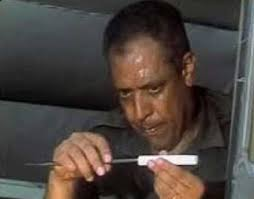
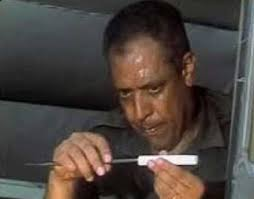

In [4]:
data_climb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4077 entries, 0 to 4076
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                4077 non-null   object 
 1   Route               4077 non-null   object 
 2   Attempted           4077 non-null   int64  
 3   Succeeded           4077 non-null   int64  
 4   Success Percentage  4077 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 159.4+ KB


In [5]:
data_wheather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464 entries, 0 to 463
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   464 non-null    object 
 1   Battery Voltage AVG    464 non-null    float64
 2   Temperature AVG        464 non-null    float64
 3   Relative Humidity AVG  464 non-null    float64
 4   Wind Speed Daily AVG   464 non-null    float64
 5   Wind Direction AVG     464 non-null    float64
 6   Solare Radiation AVG   464 non-null    float64
dtypes: float64(6), object(1)
memory usage: 25.5+ KB


#### we notice that both datasets contain no missing value but also date columns are read as strings that should be fixed
#### we notice also that there is more than a record for a single date in climb data , we just need to know number of unique dates

In [6]:
data_climb.Date.drop_duplicates().count()

391

#### to process date columns we need to transform them from string to be read as date time columns

In [7]:
data_wheather['Date'] = pd.to_datetime(data_wheather['Date'])


In [8]:
data_wheather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464 entries, 0 to 463
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   464 non-null    datetime64[ns]
 1   Battery Voltage AVG    464 non-null    float64       
 2   Temperature AVG        464 non-null    float64       
 3   Relative Humidity AVG  464 non-null    float64       
 4   Wind Speed Daily AVG   464 non-null    float64       
 5   Wind Direction AVG     464 non-null    float64       
 6   Solare Radiation AVG   464 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 25.5 KB


In [9]:
data_wheather.head()

,Date,Battery Voltage AVG,Temperature AVG,Relative Humidity AVG,Wind Speed Daily AVG,Wind Direction AVG,Solare Radiation AVG
0,2015-12-31,13.845000,19.062917,21.870833,21.977792,62.325833,84.915292
1,2015-12-30,13.822917,14.631208,18.493833,3.540542,121.505417,86.192833
2,2015-12-29,13.834583,6.614292,34.072917,0.000000,130.291667,85.100917
3,2015-12-28,13.710417,8.687042,70.557917,0.000000,164.683750,86.241250
4,2015-12-27,13.362500,14.140417,95.754167,0.000000,268.479167,31.090708


In [10]:
data_wheather['Date'].max()

Timestamp('2015-12-31 00:00:00')

In [11]:
data_wheather['Date'].min()

Timestamp('2014-09-23 00:00:00')

In [12]:
data_climb['Date'] = pd.to_datetime(data_climb['Date'])


In [13]:
data_climb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4077 entries, 0 to 4076
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                4077 non-null   datetime64[ns]
 1   Route               4077 non-null   object        
 2   Attempted           4077 non-null   int64         
 3   Succeeded           4077 non-null   int64         
 4   Success Percentage  4077 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 159.4+ KB


### Third : Aggregating climb data per date :

#### since we have multiple attempts per day , we need to get the summation of attempts and successes per day , and about route , as a categorical column , we get the mode , the most common route per day as follows :

In [14]:
data_climb.head()

,Date,Route,Attempted,Succeeded,Success Percentage
0,2015-11-27,Disappointment Cleaver,2,0,0.0
1,2015-11-21,Disappointment Cleaver,3,0,0.0
2,2015-10-15,Disappointment Cleaver,2,0,0.0
3,2015-10-13,Little Tahoma,8,0,0.0
4,2015-10-09,Disappointment Cleaver,2,0,0.0


In [15]:
data_climb.columns

Index(['Date', 'Route', 'Attempted', 'Succeeded', 'Success Percentage'], dtype='object')

In [16]:
data_climb['Date'].max()

Timestamp('2015-11-27 00:00:00')

In [17]:
data_climb['Date'].min()

Timestamp('2014-01-04 00:00:00')

In [18]:
top_routes = data_climb['Route'].value_counts().head(10).index.tolist()

# Replace rare routes with "Other"
data_climb['Route_Grouped'] = (
    data_climb['Route']
    .where(data_climb['Route'].isin(top_routes), "Other")
)

In [19]:
data_climb['Route_Grouped'].drop_duplicates()

0                 Disappointment Cleaver
3                          Little Tahoma
7                          Kautz Glacier
84                       Emmons-Winthrop
201     glacier only - no summit attempt
487                                Other
603           Liberty RIngraham Directge
1195                     Ingraham Direct
1592                    Gibralter Ledges
1835                     Fuhrer's Finger
1842                             Unknown
Name: Route_Grouped, dtype: object

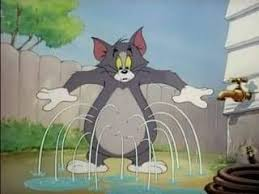
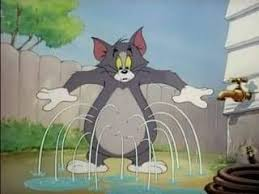

In [20]:
s=pd.get_dummies(data_climb.drop(columns =["Route"]), 'Route_Grouped').groupby(['Date']).agg({'Attempted' :'sum' ,
                                                                                       'Succeeded' :'sum' ,
                                                                                        'Success Percentage':'mean' ,
 }).sort_values(by = 'Attempted' , ascending=False)

In [21]:
s.sort_values(['Date'] , inplace=True)

In [22]:
s.columns

Index(['Attempted', 'Succeeded', 'Success Percentage'], dtype='object')

In [23]:
data_wheather.sort_values(['Date'] , inplace=True)

In [24]:
data_wheather.index = data_wheather['Date']

In [25]:
data_wheather.drop(columns = ['Date'] , inplace=True)

In [26]:
s.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 391 entries, 2014-01-04 to 2015-11-27
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Attempted           391 non-null    int64  
 1   Succeeded           391 non-null    int64  
 2   Success Percentage  391 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 12.2 KB


### Fourth : merging the 2 datasets 

#### as stated in the introduction , we need to study the effect of weather on success percentage , so we need to merge the 2 datasets

#### since we have for some dates weather statistics only and for some other dates we have climb statistics only , so we choose outer mode for merging  

In [27]:
s_pooled = pd.merge(right=data_wheather  , left = s , how = 'outer' , left_index=True, right_index=True)

#### regarding missing values in the pooled dataset due to merging , we assume days in which no records for climbing data , we assume they had zero attempts , successes 

In [28]:
s_pooled[s.columns] = s_pooled[s.columns].fillna(0)

and about days with missing climate daa , since they are climate data they are almost the same  in the same day across years , so we replace days with missing with the same days data from the last or succseeding year

In [29]:
def fill_missing_vectorized(df, value_columns):
    filled_df = df.copy()
    filled_df['month_day'] = filled_df.index.strftime('%m-%d')
    
    for col in value_columns:
        grouped = filled_df.groupby('month_day')[col]
        
        # Forward fill (next year) then backward fill (previous year)
        ffilled = grouped.ffill()
        bfilled = grouped.bfill()
        filled = bfilled.where(bfilled.notna(), ffilled)
        #then if a certain month day is missing in both years , we componsate it by the following or previous day
        filled_df[col] = filled.bfill().ffill()
    
    filled_df = filled_df.drop(columns=['month_day'])
    return filled_df

In [30]:
s_pooled = fill_missing_vectorized(s_pooled, ['Battery Voltage AVG', 'Temperature AVG', 'Relative Humidity AVG', 
            'Wind Speed Daily AVG', 'Wind Direction AVG' , 'Solare Radiation AVG'])

In [31]:
s_pooled['weekday'] = s_pooled.index.dayofweek  

In [32]:
s_pooled['month'] = s_pooled.index.month

In [33]:
s_pooled.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 651 entries, 2014-01-04 to 2015-12-31
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Attempted              651 non-null    float64
 1   Succeeded              651 non-null    float64
 2   Success Percentage     651 non-null    float64
 3   Battery Voltage AVG    651 non-null    float64
 4   Temperature AVG        651 non-null    float64
 5   Relative Humidity AVG  651 non-null    float64
 6   Wind Speed Daily AVG   651 non-null    float64
 7   Wind Direction AVG     651 non-null    float64
 8   Solare Radiation AVG   651 non-null    float64
 9   weekday                651 non-null    int32  
 10  month                  651 non-null    int32  
dtypes: float64(9), int32(2)
memory usage: 55.9 KB


# EDA

#### we first make sure that date column is the index of our dataset 

#### we plot the series of attempt 

In [34]:
Attempt = s_pooled['Succeeded']
Attempt.head()

Date
2014-01-04    2.0
2014-01-05    0.0
2014-01-06    0.0
2014-01-16    0.0
2014-01-18    4.0
Name: Succeeded, dtype: float64

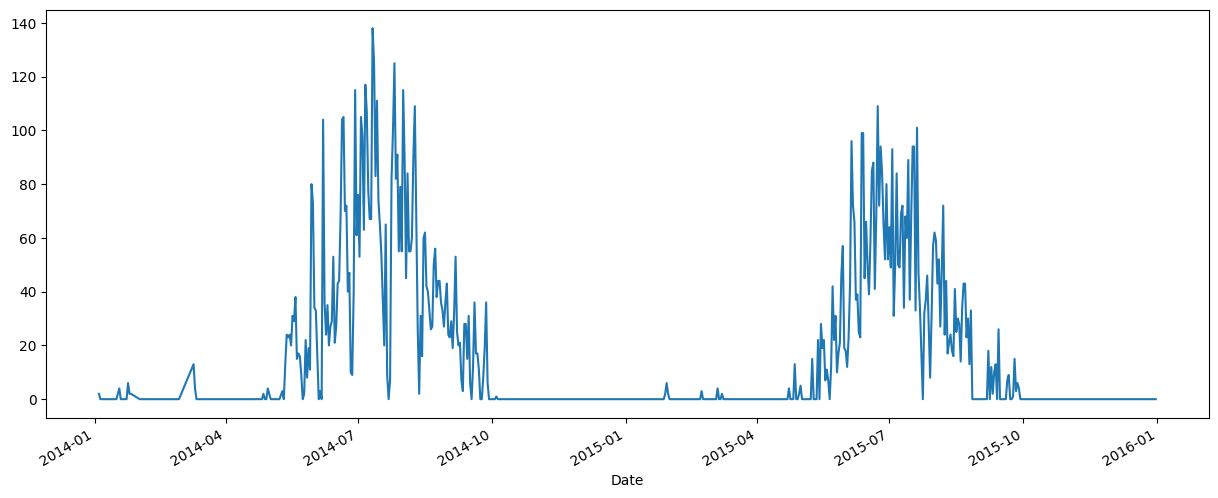

In [35]:
Attempt.plot(figsize=(15, 6))
plt.show()

#### from the above plot we notice that attempts act as a seasonal time series , so we 'd better to study it using SARIMA time series process , weather columns as exogenous  variables 

#### then we use ARIMA models , for more check the following link :https://towardsdatascience.com/an-end-to-end-project-on-time-series-analysis-and-forecasting-with-python-4835e6bf050b

#### the idea is we fit several models for our series , and take the model with the least AIC , as the best fitting model for the series 

before that , first we have to preprocess our exogeous variables

#### We will work on success percentage as a dependent column on weather columns , so we first do some descriptive statistics , distribution plots for each column of them 

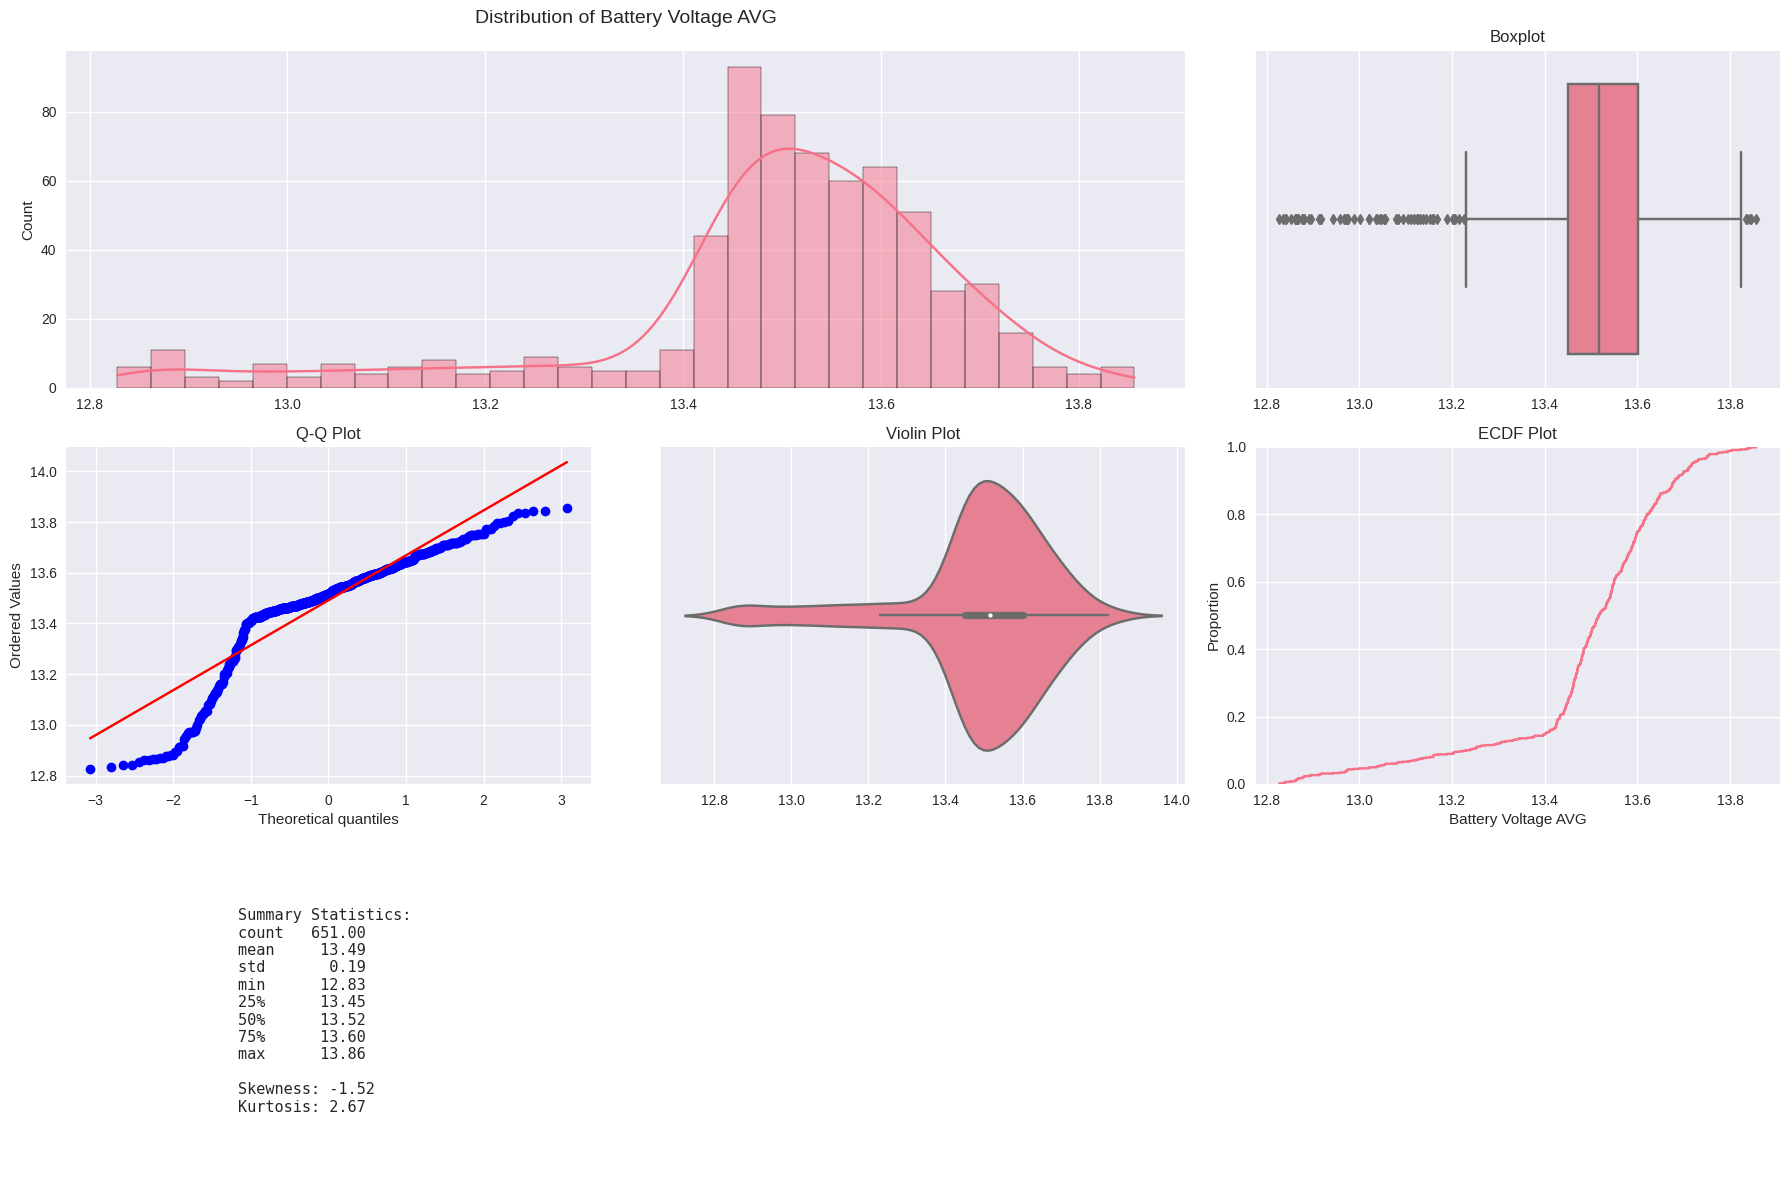

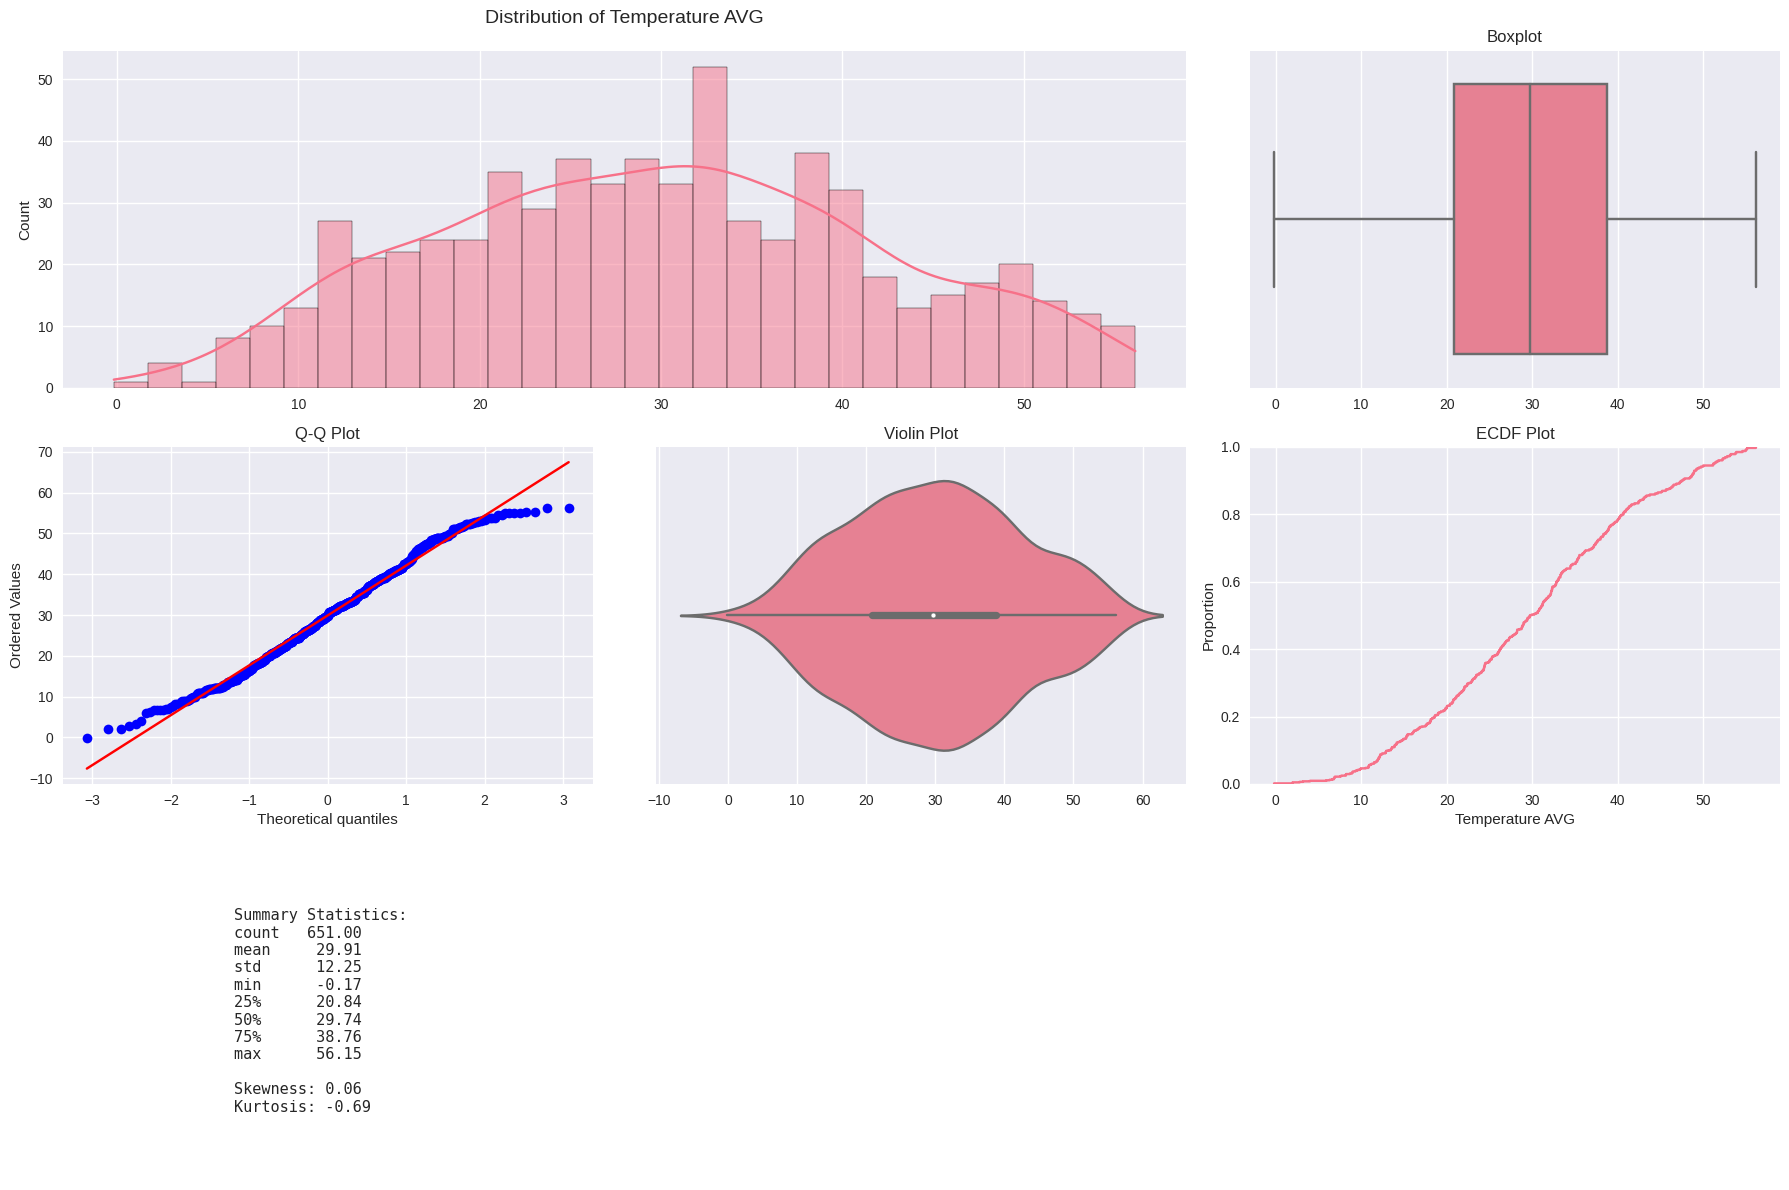

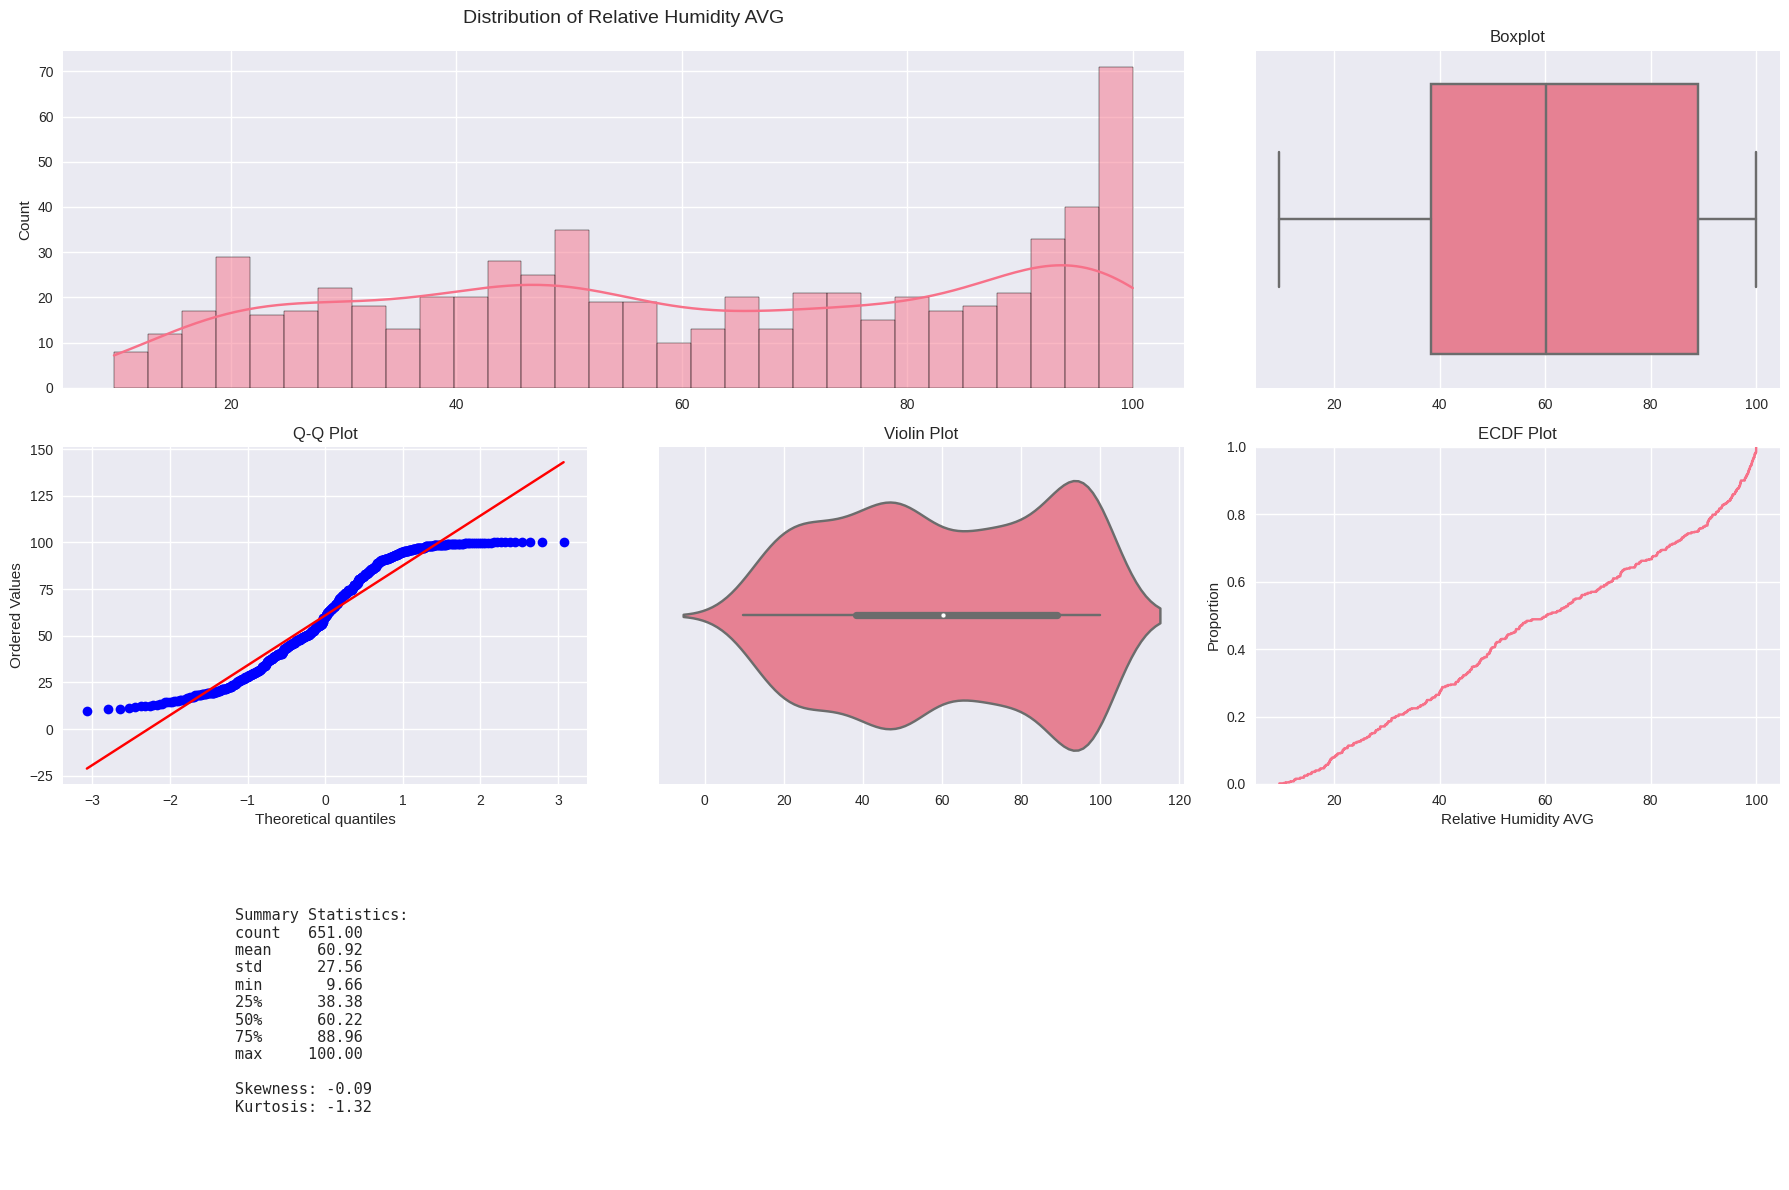

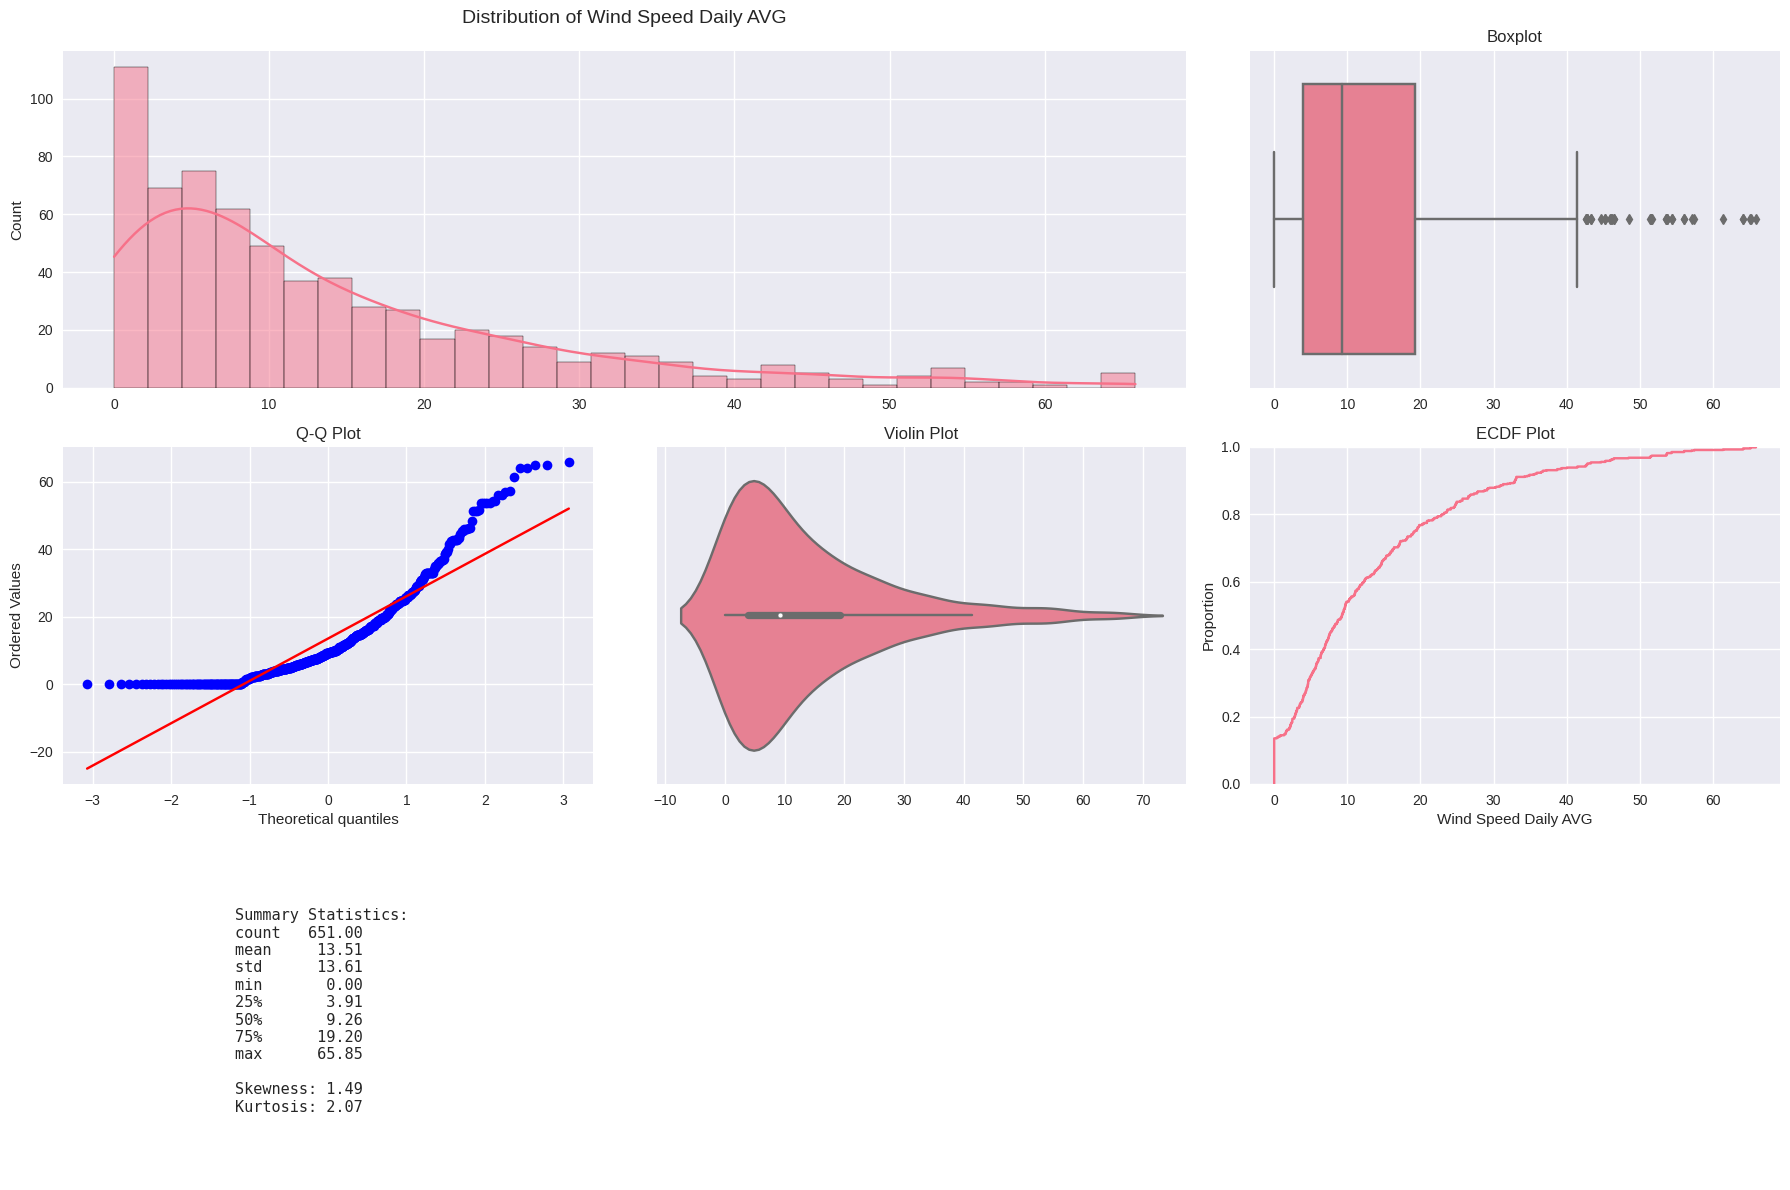

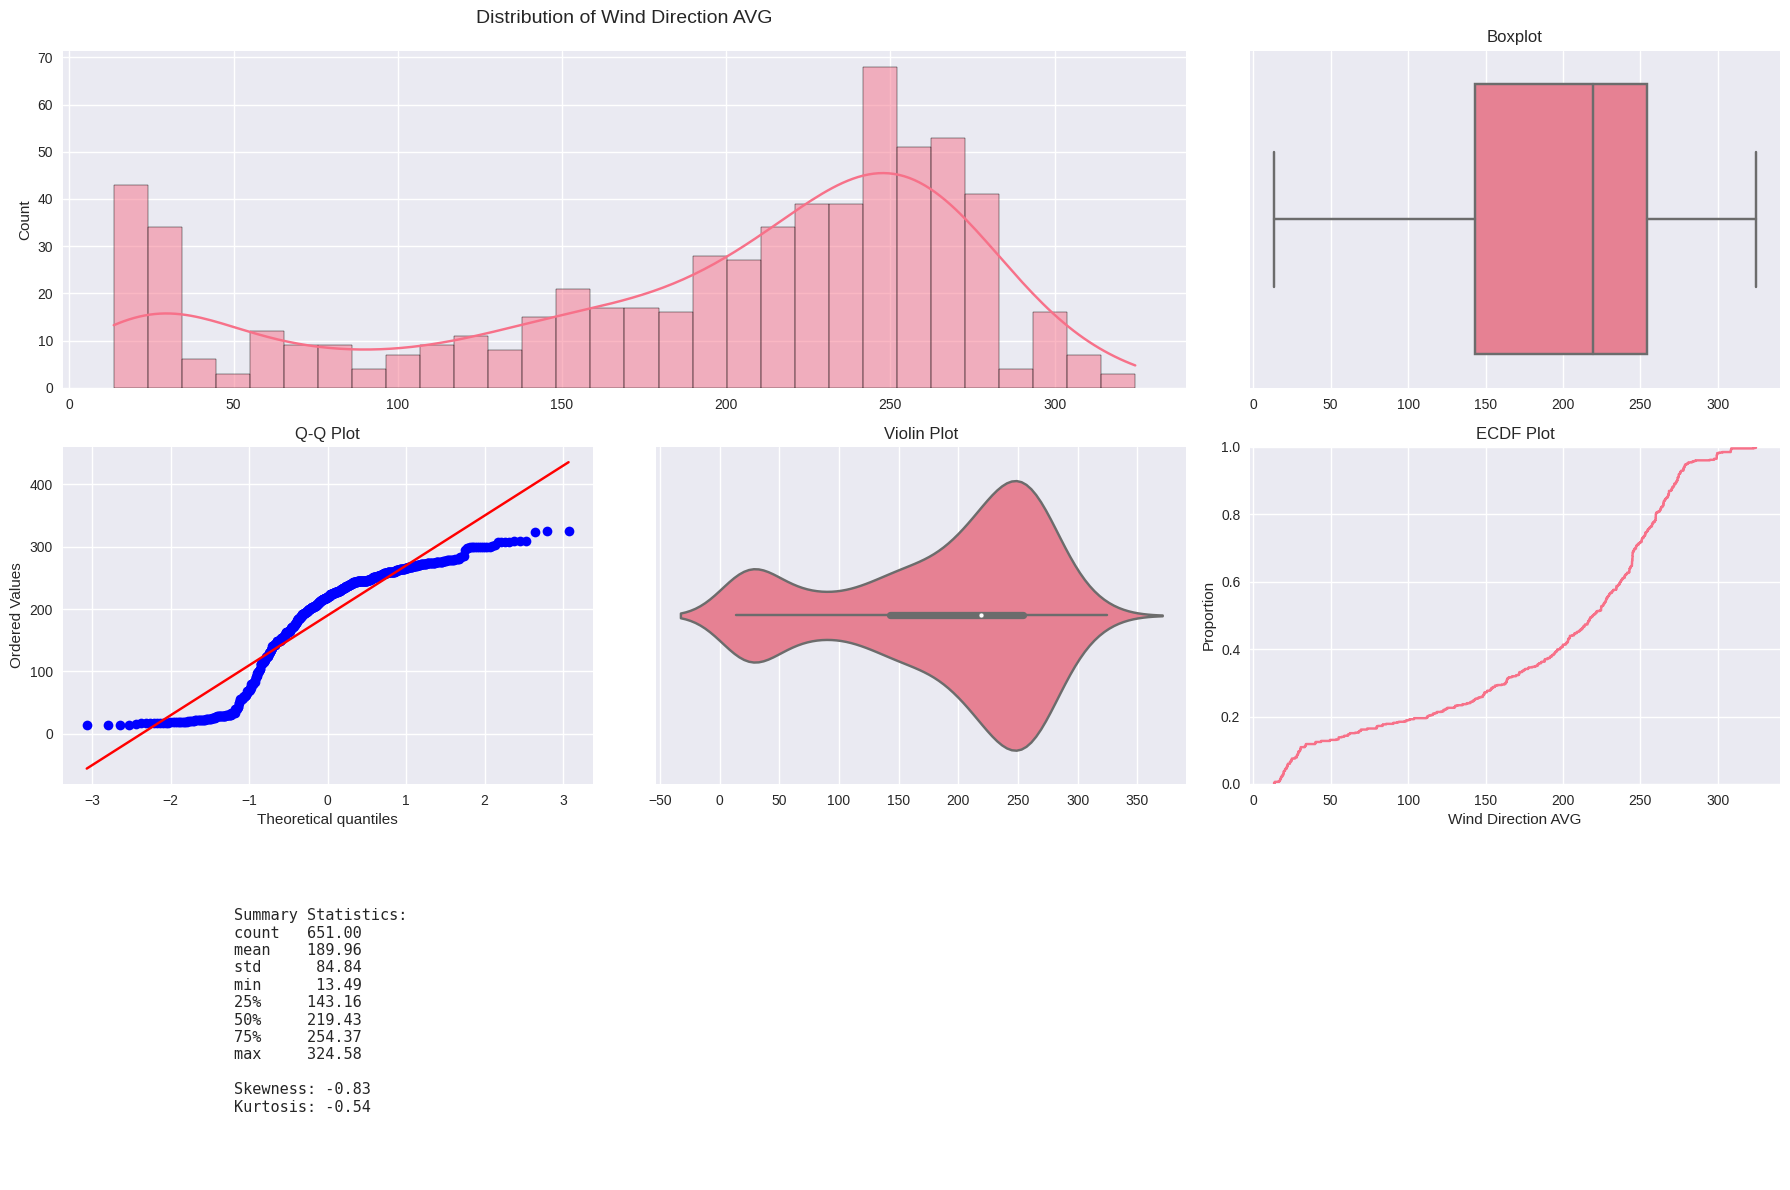

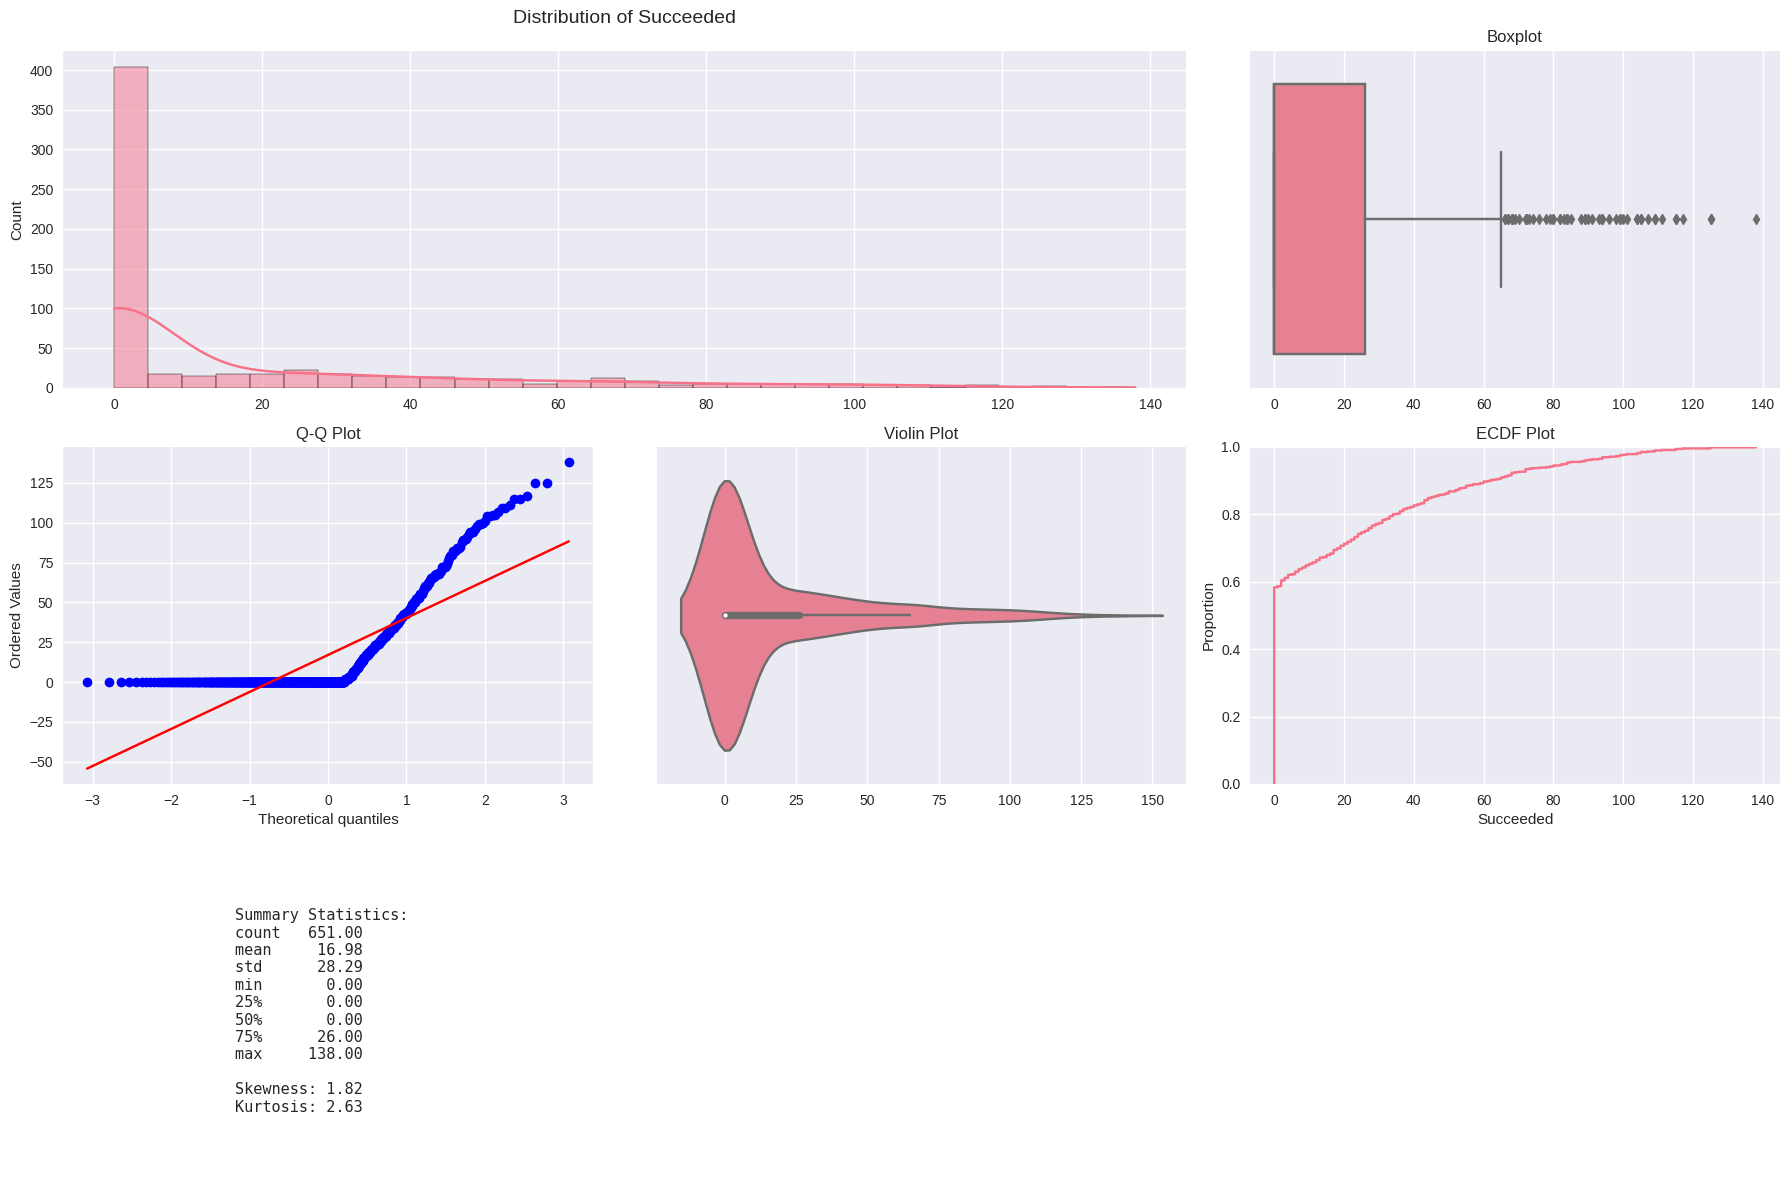

In [36]:


# Set style for better visuals
plt.style.use('seaborn')
sns.set_palette("husl")

features = ['Battery Voltage AVG', 'Temperature AVG', 'Relative Humidity AVG', 
            'Wind Speed Daily AVG', 'Wind Direction AVG', 'Succeeded']

def enhanced_distribution_analysis(df, feature):
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(18, 12))
    grid = plt.GridSpec(3, 3, figure=fig)
    
    # Clean data - remove missing values
    clean_data = df[feature].dropna()
    
    # 1. Main Distribution Plot
    ax1 = fig.add_subplot(grid[0, :2])
    sns.histplot(data=clean_data, kde=True, ax=ax1, bins=30)
    ax1.set_title(f'Distribution of {feature}', fontsize=14, pad=20)
    ax1.set_xlabel('')
    
    # 2. Boxplot
    ax2 = fig.add_subplot(grid[0, 2])
    sns.boxplot(x=clean_data, ax=ax2)
    ax2.set_title('Boxplot', fontsize=12)
    ax2.set_xlabel('')
    
    # 3. Q-Q Plot
    ax3 = fig.add_subplot(grid[1, 0])
    stats.probplot(clean_data, dist="norm", plot=ax3)
    ax3.set_title('Q-Q Plot', fontsize=12)
    
    # 4. Violin Plot
    ax4 = fig.add_subplot(grid[1, 1])
    sns.violinplot(x=clean_data, ax=ax4)
    ax4.set_title('Violin Plot', fontsize=12)
    ax4.set_xlabel('')
    
    # 5. ECDF Plot
    ax5 = fig.add_subplot(grid[1, 2])
    sns.ecdfplot(data=clean_data, ax=ax5)
    ax5.set_title('ECDF Plot', fontsize=12)
    
    # 6. Summary Statistics
    ax6 = fig.add_subplot(grid[2, :])
    stats_text = clean_data.describe().to_string(float_format="%.2f")
    skew_kurt = f"Skewness: {clean_data.skew():.2f}\nKurtosis: {clean_data.kurtosis():.2f}"
    ax6.text(0.1, 0.5, f"Summary Statistics:\n{stats_text}\n\n{skew_kurt}", 
             fontfamily='monospace', fontsize=11, va='center')
    ax6.axis('off')
    
    plt.tight_layout()
    plt.show()

# Analyze each feature
for feature in features:
    enhanced_distribution_analysis(s_pooled, feature)

#### we notice that all columns close to normal distribution except the severe right skewness of 'wind speed AVG' and 'solar radiation AVG' , we may need log transformation to get rid of this skewness but it may lead to less goodness of fit in practice 
#### we take only needed columns , weather columns and successful percentage in a new dataset 


In [37]:
s_pooled.head()

,Attempted,Succeeded,Success Percentage,Battery Voltage AVG,Temperature AVG,Relative Humidity AVG,Wind Speed Daily AVG,Wind Direction AVG,Solare Radiation AVG,weekday,month
Date,,,,,,,,,,,
2014-01-04,3.0,2.0,0.666667,13.418750,20.746667,93.022917,43.286667,277.700000,0.0,5,1
2014-01-05,2.0,0.0,0.000000,13.305833,28.823333,80.260833,42.825417,297.620833,0.0,6,1
2014-01-06,16.0,0.0,0.000000,13.549583,36.910000,21.617500,18.962500,278.133333,0.0,0,1
2014-01-16,2.0,0.0,0.000000,13.678333,18.130000,44.974167,16.174917,251.220833,0.0,3,1
2014-01-18,8.0,4.0,0.333333,13.478750,13.492500,96.029167,45.288750,204.462500,0.0,5,1


In [38]:
s_pooled.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 651 entries, 2014-01-04 to 2015-12-31
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Attempted              651 non-null    float64
 1   Succeeded              651 non-null    float64
 2   Success Percentage     651 non-null    float64
 3   Battery Voltage AVG    651 non-null    float64
 4   Temperature AVG        651 non-null    float64
 5   Relative Humidity AVG  651 non-null    float64
 6   Wind Speed Daily AVG   651 non-null    float64
 7   Wind Direction AVG     651 non-null    float64
 8   Solare Radiation AVG   651 non-null    float64
 9   weekday                651 non-null    int32  
 10  month                  651 non-null    int32  
dtypes: float64(9), int32(2)
memory usage: 55.9 KB


#### we find that there are missing values in weather columns since we have days we have climb statistics for but with no data for weather , in this case we don't include these cases in our analysis.

#### We shoulf notice that the sample here will be onlt 464 cases which we divide to train and test data , so results shoulf be taken carefully , we would have more accurate results if we had a larger sample 

#### we have the categorical columns if route which we should include in our analysis , we will make binary column for each category to include in our analysis.


#### from the above frequencies table we take a binary column to include in our analysis for the most common 3 route patterns 

#### before that let's check correlation between the columns 

<Axes: >

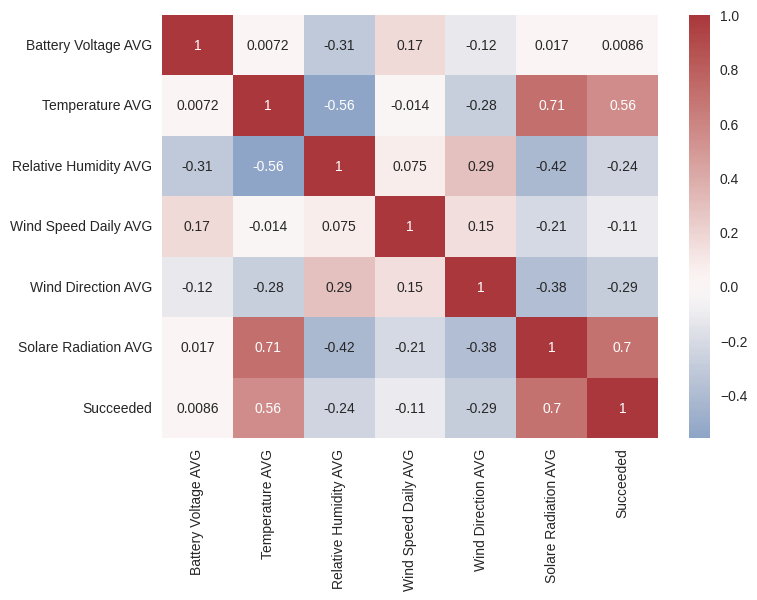

In [39]:
sns.heatmap(s_pooled.loc[np.isnan(s_pooled['Battery Voltage AVG']) ==0,['Battery Voltage AVG','Temperature AVG','Relative Humidity AVG','Wind Speed Daily AVG','Wind Direction AVG'
                ,'Solare Radiation AVG', 'Succeeded']].corr() , center =0 , cmap = 'vlag' , annot=True)

#### we notice that the most correlating column with success percentage is solar radiation , which makes sense , helping the climber with warmness and light 

#### also we notice high correlation between temprature and solar radiation , which violates one of regression assumptions which is absence of collinearity between regressors , so we can exclude it from analysis

#### then let's have a look on data

In [40]:
s_pooled = s_pooled.sort_values(by = 'Date',ascending=True )

In [41]:
predictors = s_pooled.drop(columns = ['Success Percentage' , 'Succeeded' ,  'Attempted' ]).columns

In [42]:
predictors

Index(['Battery Voltage AVG', 'Temperature AVG', 'Relative Humidity AVG',
       'Wind Speed Daily AVG', 'Wind Direction AVG', 'Solare Radiation AVG',
       'weekday', 'month'],
      dtype='object')

### Seventh : Predecting attempts' success

#### so regarding data we will predict success percentage through we will take cases only with valid data for weather columns , include columns for the most common 3 route patterns  , and exclude temprature AVG column to maintain absence of collinearity assumption for regression 

In [43]:
X = s_pooled.dropna(how='any').loc[:,predictors]

In [44]:
X.head()

,Battery Voltage AVG,Temperature AVG,Relative Humidity AVG,Wind Speed Daily AVG,Wind Direction AVG,Solare Radiation AVG,weekday,month
Date,,,,,,,,
2014-01-04,13.418750,20.746667,93.022917,43.286667,277.700000,0.0,5,1
2014-01-05,13.305833,28.823333,80.260833,42.825417,297.620833,0.0,6,1
2014-01-06,13.549583,36.910000,21.617500,18.962500,278.133333,0.0,0,1
2014-01-16,13.678333,18.130000,44.974167,16.174917,251.220833,0.0,3,1
2014-01-18,13.478750,13.492500,96.029167,45.288750,204.462500,0.0,5,1


In [45]:
y = s_pooled.dropna(how='any').loc[:,'Succeeded']

In [46]:
def log_tras (series):
    result = series.apply(lambda x: np.log(x)   if (np.round(x,3) != 0  ) else 0 )
    return result 
def exp_tras (series):
    result = series.apply(lambda x: np.exp(x)   if (np.round(x,3) != 0  ) else 0 )
    return result 

In [47]:
x_final = X.copy(deep=True)

In [48]:
# from sklearn.decomposition import PCA

climate_features = ['Temperature AVG', 'Relative Humidity AVG', 'Wind Speed Daily AVG',
                     'Wind Direction AVG', 'Solare Radiation AVG']

# # X_scaled = MinMaxScaler().fit_transform(x_final[climate_features])
# # pca = PCA(n_components=2)  # try reducing to 3 components
# # X_pca = pca.fit_transform(X_scaled)

# # # Add compressed features back to df
# # for i in range(X_pca.shape[1]):
# #     x_final[f'pca_climate_{i+1}'] = X_pca[:, i]

# for col in climate_features:
#     # First and second lag
#     x_final[f'{col}_lag1'] = x_final[col].shift(1).bfill()
#     x_final[f'{col}_lag2'] = x_final[col].shift(2).bfill()
#     x_final[f'{col}_lag90'] = x_final[col].shift(90).bfill()


#     # First and second moving average (window=2 and window=3)
#     x_final[f'{col}_ma2'] = x_final[col].shift(1).rolling(window=2).mean().bfill()
#     x_final[f'{col}_ma3'] = x_final[col].shift(1).rolling(window=3).mean().bfill()
#     x_final[f'{col}_ma90'] = x_final[col].shift(90).rolling(window=3).mean().bfill()

#     x_final.fillna(0, inplace=True)

In [49]:
from sklearn.base import BaseEstimator, TransformerMixin

class TimeSeriesLagTransformer(BaseEstimator, TransformerMixin):
    """Creates lag and rolling features without data leakage"""
    def __init__(self, lag_periods=[1, 7 ,90], roll_windows=[2, 8,90] , columns=None):
        self.lag_periods = lag_periods
        self.roll_windows = roll_windows
        self.columns=columns
    
    def fit(self, X, y=None , columns=None):
        # No fitting needed for this transformer
        return self
    
    def transform(self, X ):
        """Compute lags and rolling stats on X (assumed to be in chronological order)"""
        X_transformed = X.copy()
        
        # Create lag features
        for col in self.columns:
            for lag in self.lag_periods:
                X_transformed[f'{col}_lag{lag}'] = X[col].shift(lag).fillna(0)
                
            # Create rolling features
            for window in self.roll_windows:
                X_transformed[f'{col}_ma{window}'] = (
                    X[col].shift(1)  # Avoid leakage from current observation
                    .rolling(window=window)
                    .mean()
                    .fillna(0)
                )
        
        return X_transformed

In [50]:
lags_tr=TimeSeriesLagTransformer(columns=climate_features)

In [51]:
TimeSeriesLagTransformer(columns=climate_features).transform(X)

,Battery Voltage AVG,Temperature AVG,Relative Humidity AVG,Wind Speed Daily AVG,Wind Direction AVG,Solare Radiation AVG,weekday,month,Temperature AVG_lag1,Temperature AVG_lag7,...,Wind Direction AVG_lag90,Wind Direction AVG_ma2,Wind Direction AVG_ma8,Wind Direction AVG_ma90,Solare Radiation AVG_lag1,Solare Radiation AVG_lag7,Solare Radiation AVG_lag90,Solare Radiation AVG_ma2,Solare Radiation AVG_ma8,Solare Radiation AVG_ma90
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-04,13.418750,20.746667,93.022917,43.286667,277.700000,0.000000,5,1,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2014-01-05,13.305833,28.823333,80.260833,42.825417,297.620833,0.000000,6,1,20.746667,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2014-01-06,13.549583,36.910000,21.617500,18.962500,278.133333,0.000000,0,1,28.823333,0.000000,...,0.000000,287.660417,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2014-01-16,13.678333,18.130000,44.974167,16.174917,251.220833,0.000000,3,1,36.910000,0.000000,...,0.000000,287.877083,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2014-01-18,13.478750,13.492500,96.029167,45.288750,204.462500,0.000000,5,1,18.130000,0.000000,...,0.000000,264.677083,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-27,13.362500,14.140417,95.754167,0.000000,268.479167,31.090708,6,12,17.512917,6.817417,...,270.866667,268.472917,252.094271,212.375362,43.407208,62.243792,201.852583,65.108854,58.766016,82.798817
2015-12-28,13.710417,8.687042,70.557917,0.000000,164.683750,86.241250,0,12,14.140417,8.244375,...,270.208333,268.472917,255.030208,212.348835,31.090708,24.127125,195.923167,37.248958,53.115062,80.901463
2015-12-29,13.834583,6.614292,34.072917,0.000000,130.291667,85.100917,1,12,8.687042,4.028125,...,216.934167,216.581458,244.996927,211.176339,86.241250,70.343500,202.812750,58.665979,56.114745,79.682775


In [52]:
# pca.explained_variance_ratio_


In [53]:
# loadings = pd.DataFrame(
#     pca.components_,
#     columns=climate_features,  # your original feature names
#     index=[f'PC{i+1}' for i in range(pca.n_components_)]
# )

In [54]:
# loadings

In [55]:
# x_final.drop(columns = climate_features , inplace=True)

In [56]:
def test_stationarity(timeseries):
    # Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries,
                      autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (round(dfoutput,3))

In [57]:
test_stationarity(y )

Results of Dickey-Fuller Test:
Test Statistic                  -1.376
p-value                          0.594
#Lags Used                      20.000
Number of Observations Used    630.000
Critical Value (1%)             -3.441
Critical Value (5%)             -2.866
Critical Value (10%)            -2.569
dtype: float64


In [58]:
test_stationarity(y.diff().dropna() )

Results of Dickey-Fuller Test:
Test Statistic                  -7.810
p-value                          0.000
#Lags Used                      20.000
Number of Observations Used    629.000
Critical Value (1%)             -3.441
Critical Value (5%)             -2.866
Critical Value (10%)            -2.569
dtype: float64


In [59]:
# x_transformed = pd.DataFrame(StandardScaler().fit_transform(x_final))
# x_transformed.index = x_final.index
# x_transformed.columns = x_final.columns


# Modeling

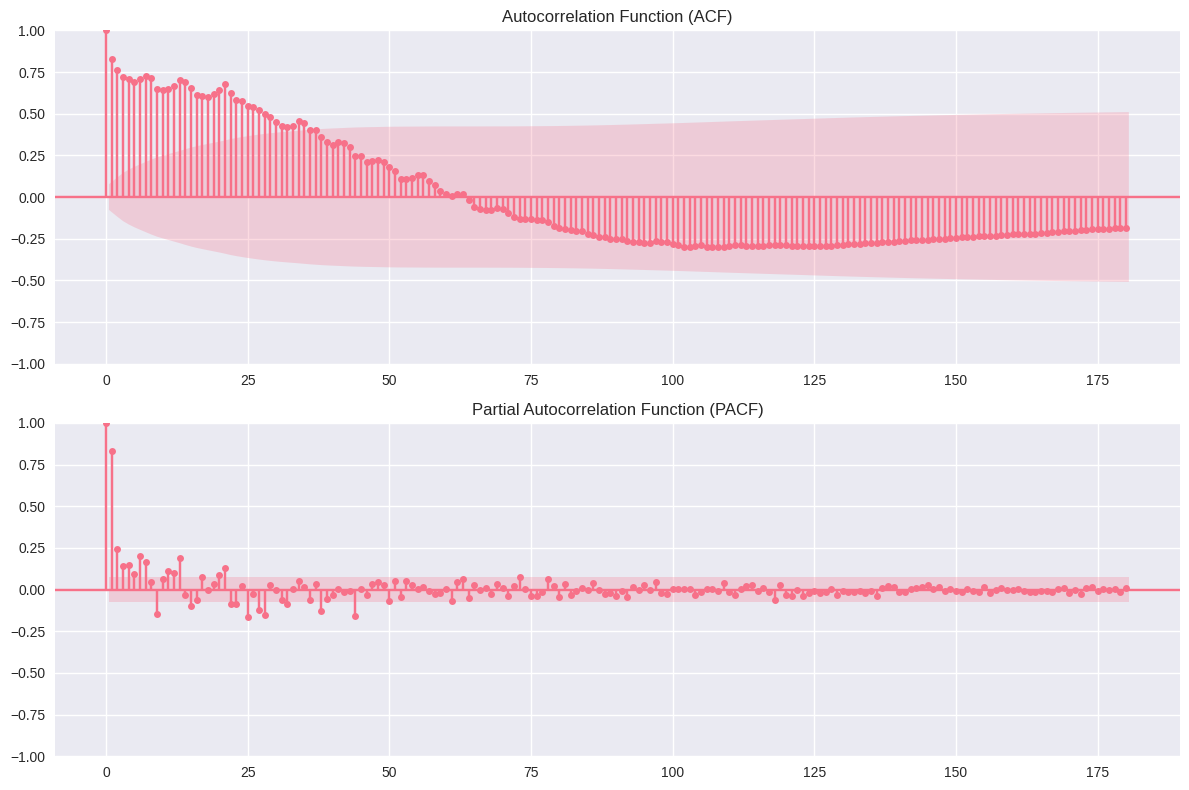

In [60]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for stationary data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# ACF plot (to identify MA(q) terms)
plot_acf(y, lags=180, ax=ax1, title="Autocorrelation Function (ACF)")

# PACF plot (to identify AR(p) terms)
plot_pacf(y, lags=180, ax=ax2, title="Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

In [61]:
y_diffed=y.diff().dropna()

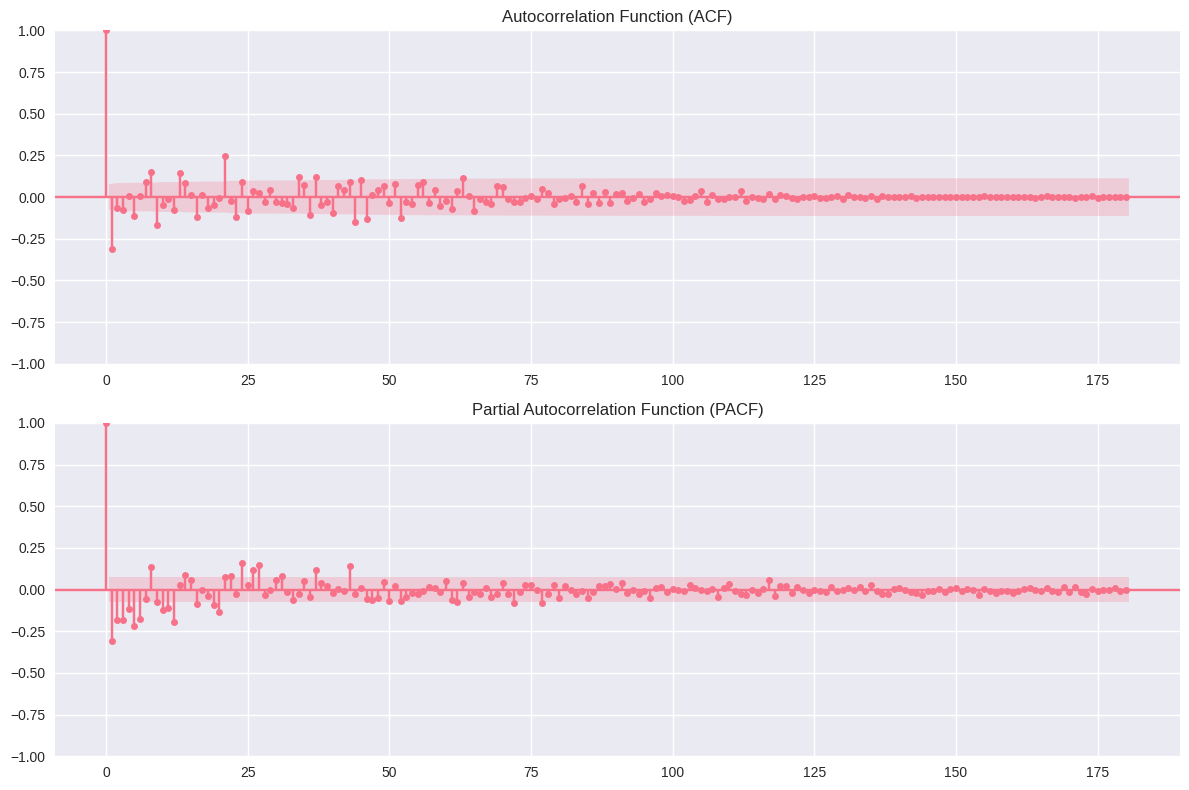

In [62]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for stationary data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# ACF plot (to identify MA(q) terms)
plot_acf(y_diffed, lags=180, ax=ax1, title="Autocorrelation Function (ACF)")

# PACF plot (to identify AR(p) terms)
plot_pacf(y_diffed, lags=180, ax=ax2, title="Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

In [63]:
y_diffed=y.diff(120).dropna()

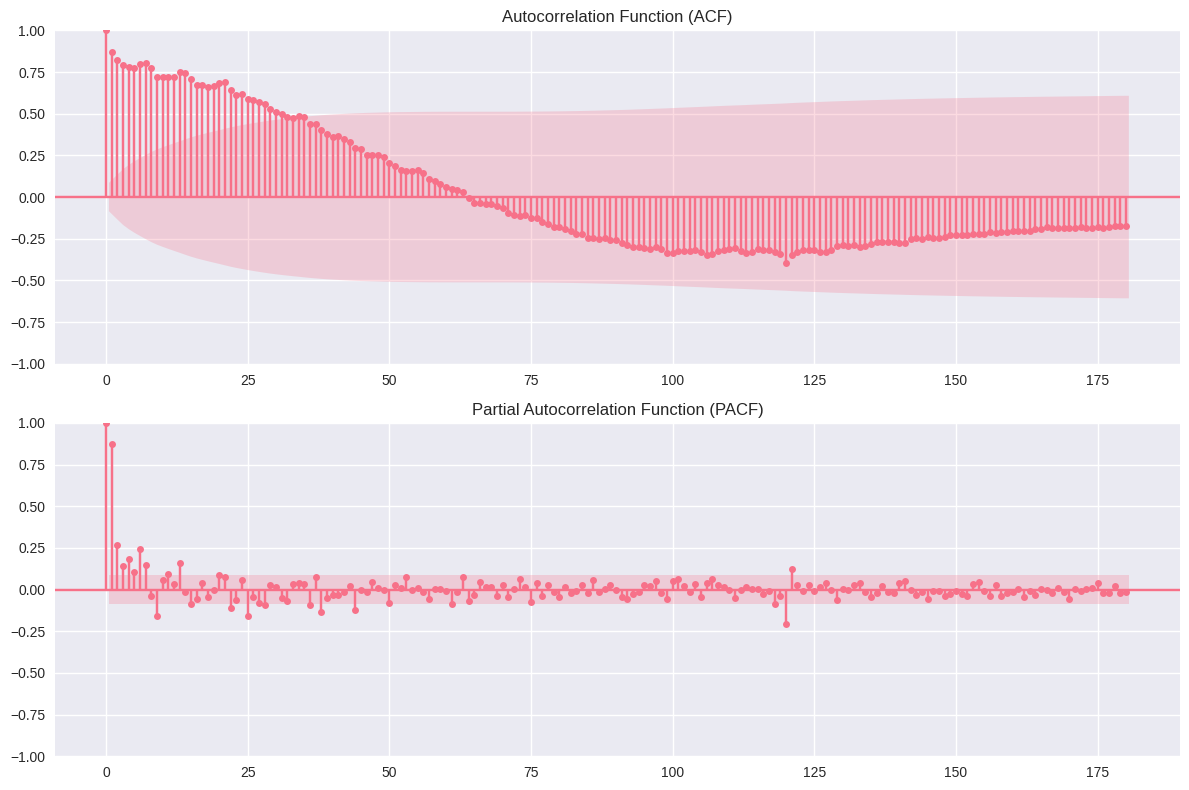

In [64]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for stationary data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# ACF plot (to identify MA(q) terms)
plot_acf(y_diffed, lags=180, ax=ax1, title="Autocorrelation Function (ACF)")

# PACF plot (to identify AR(p) terms)
plot_pacf(y_diffed, lags=180, ax=ax2, title="Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

## Classical time series (SARIMAX)

In [65]:
# lambda_y= stats.boxcox(y[y>0])[1]
# #y_final = boxcox1p(y, lambda_y)
y_final = np.sqrt(y)

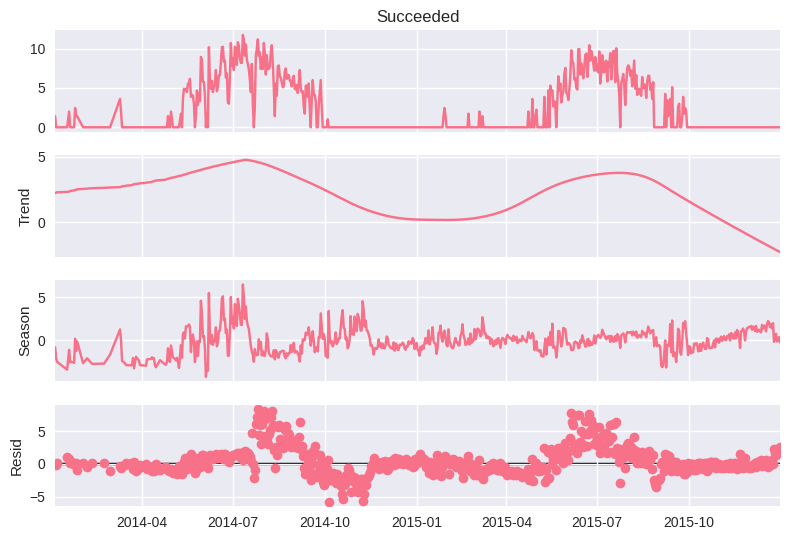

In [66]:
stl = STL(y_final,period=120,robust=True)
res = stl.fit()
fig = res.plot()

#### then we divide data into train and test datasets 

In [67]:
s_pooled.index[int(np.round(s_pooled.shape[0]*0.7, 0) )]

Timestamp('2015-06-20 00:00:00')

In [68]:
x_final

,Battery Voltage AVG,Temperature AVG,Relative Humidity AVG,Wind Speed Daily AVG,Wind Direction AVG,Solare Radiation AVG,weekday,month
Date,,,,,,,,
2014-01-04,13.418750,20.746667,93.022917,43.286667,277.700000,0.000000,5,1
2014-01-05,13.305833,28.823333,80.260833,42.825417,297.620833,0.000000,6,1
2014-01-06,13.549583,36.910000,21.617500,18.962500,278.133333,0.000000,0,1
2014-01-16,13.678333,18.130000,44.974167,16.174917,251.220833,0.000000,3,1
2014-01-18,13.478750,13.492500,96.029167,45.288750,204.462500,0.000000,5,1
...,...,...,...,...,...,...,...,...
2015-12-27,13.362500,14.140417,95.754167,0.000000,268.479167,31.090708,6,12
2015-12-28,13.710417,8.687042,70.557917,0.000000,164.683750,86.241250,0,12
2015-12-29,13.834583,6.614292,34.072917,0.000000,130.291667,85.100917,1,12


In [69]:
tr_start,  tr_end , = '2014-01-04','2015-06-20'
#val_start, val_end = '2015-06-21','2015-09-25'
te_start, te_end = '2015-06-21','2015-12-31'

x_train , x_test = X[tr_start : tr_end] , X[te_start :te_end]
y_train , y_test =  y[tr_start : tr_end] , y[te_start :te_end]

In [70]:
train_sets = []
val_sets = []

In [71]:
from sklearn.model_selection import TimeSeriesSplit
# # Usage Example
# n_splits = 3
# test_size = 60  # Fixed validation size
# train_size = 270  # Fixed training size (e.g., 1 year)

# # Initialize splitter
# tscv = equal_train_timeseries_split(
#     n_splits=n_splits,
#     test_size=test_size,
#     train_size=train_size
# )


# Initialize splitter
tscv = TimeSeriesSplit(n_splits=3)
# # Visualize splits
# for fold, (train_idx, val_idx) in enumerate(fixed_window_cv(x_train , train_size=270, val_size=90, n_splits=3)):
#     train_sets.append(x_train.index[train_idx])
#     val_sets.append(x_train.index[val_idx])
#     print(f"\nFold {fold + 1}:")
#     print(f"Train: {x_final.index[train_idx[0]]} to {x_final.index[train_idx[-1]]} "
#           f"(size: {len(train_idx)})")
#     print(f"Val:   {x_final.index[val_idx[0]]} to {x_final.index[val_idx[-1]]} "
#           f"(size: {len(val_idx)})")


# Visualize splits
def fixed_window_cv(data, train_size, val_size, n_splits):
    for i in range(n_splits):
        start = i * val_size
        train_end = start + train_size
        val_end = train_end + val_size
        train, val = data[start:train_end].index, data[train_end:val_end].index
        yield train, val

# # Usage
# for train, val in fixed_window_cv(data, train_size=270, val_size=90, n_splits=3):
#     print(f"Train: {len(train)}, Val: {len(val)}")


# Visualize splits
for fold, (train_idx, val_idx) in enumerate(fixed_window_cv(x_train , train_size=140, val_size=60, n_splits=5)):
    train_sets.append(train_idx)
    val_sets.append(val_idx)
    print(f"\nFold {fold + 1}:")
    print(f"Train: {train_idx[0]} to {train_idx[-1]} "
          f"(size: {len(train_idx)})")
    print(f"Train: {val_idx[0]} to {val_idx[-1]} "
          f"(size: {len(val_idx)})")



Fold 1:
Train: 2014-01-04 00:00:00 to 2014-08-07 00:00:00 (size: 140)
Train: 2014-08-08 00:00:00 to 2014-10-06 00:00:00 (size: 60)

Fold 2:
Train: 2014-05-20 00:00:00 to 2014-10-06 00:00:00 (size: 140)
Train: 2014-10-07 00:00:00 to 2014-12-05 00:00:00 (size: 60)

Fold 3:
Train: 2014-07-19 00:00:00 to 2014-12-05 00:00:00 (size: 140)
Train: 2014-12-06 00:00:00 to 2015-02-03 00:00:00 (size: 60)

Fold 4:
Train: 2014-09-17 00:00:00 to 2015-02-03 00:00:00 (size: 140)
Train: 2015-02-04 00:00:00 to 2015-04-04 00:00:00 (size: 60)

Fold 5:
Train: 2014-11-16 00:00:00 to 2015-04-04 00:00:00 (size: 140)
Train: 2015-04-05 00:00:00 to 2015-06-03 00:00:00 (size: 60)


In [72]:
# d=range(1,2)
# D= range(0,1)

# p = range(0, 2)
# q = range(0, 2)
# P = range(0, 2)
# Q = range(0, 2)
# m = 120
# best_r2 = -np.inf
# best_mse = np.inf

# r=0

# for pdq in itertools.product(p, d, q):

#     for seasonal_pdq in itertools.product(P, D, Q, [m]):
#             # if r > t-1 :
#             #     break
#             train_id = next(train_iterator)
#             val_id = next(val_iterator)
#             y_train = y[train_id]
#             y_val = y[val_id]
#             tr_start=train_id[0]
#             tr_end=train_id[-1]
        

        
#         # try:
#             model = SARIMAX(np.sqrt(y_train),
#                           order=pdq,
#                           seasonal_order=seasonal_pdq)
#             results = model.fit()
            
#             # Get predictions
#             pred_train = results.get_prediction(start=tr_start, end=tr_end)
#             forecast_steps = len(y_val)
#             pred_test = results.get_forecast(steps=forecast_steps)

#             # Calculate R²
#             train_r2 = r2_score(y_train,np.power(pred_train.predicted_mean, 2))
#             val_r2 = r2_score(y_val, np.power (pred_test.predicted_mean, 2))
#             val_mse = mean_squared_error(y_val,np.power (pred_test.predicted_mean,2))
#             # output_sarima.loc[len(output_sarima)] = [str(pdq) + str(seasonal_pdq), train_r2 , val_mse , val_r2 , 0]

#             if val_r2 > best_r2 :
#                 best_mse = val_mse
#                 best_model = model
#                 best_fit = results
                
                
                
                
                

                           
#             print(f'SARIMA{pdq}{seasonal_pdq} - val_R²: {val_r2*100:.2f}%  - val_RMSE : {np.sqrt(val_mse):.2f}')
#             # r+=1

            
#         # except:
#         #    continue




In [73]:
tr_start,  tr_end , = '2014-01-04','2015-06-20'
#val_start, val_end = '2015-06-21','2015-09-25'
te_start, te_end = '2015-06-21','2015-12-31'

x_train , x_test = X[tr_start : tr_end] , X[te_start :te_end]
y_train , y_test =  y[tr_start : tr_end] , y[te_start :te_end]

In [74]:
# model = SARIMAX(np.sqrt(y_train), exog = TimeSeriesLagTransformer(columns=climate_features).transform(x_train) ,
#                           order=(1,0,1),
#                           seasonal_order=(1,0,0 ,120))
# results = model.fit()

In [75]:
# significance = results.pvalues

In [76]:
# (significance[significance<=0.3]).plot(kind='bar')

In [77]:
# new_vars = [x for x in list(significance[significance<=0.3].index) if x in TimeSeriesLagTransformer(columns = climate_features).transform(x_train).columns]

In [78]:
new_vars = ['Temperature AVG',
 'Wind Direction AVG',
 'Solare Radiation AVG',
 'weekday',
 'Temperature AVG_lag1',
 'Temperature AVG_lag7',
 'Temperature AVG_ma2',
 'Temperature AVG_ma8',
 'Temperature AVG_ma90',
 'Relative Humidity AVG_lag90',
 'Relative Humidity AVG_ma90',
 'Wind Direction AVG_lag1',
 'Wind Direction AVG_ma2',
 'Wind Direction AVG_ma8',
 'Solare Radiation AVG_lag90']

In [79]:
output_sarima =  pd.DataFrame({
    'model rank': pd.Series(dtype='object'),
    'R2_train': pd.Series(dtype='float32'),  # pandas Boolean (supports NA)
    'MSE_val': pd.Series(dtype='float32') , 
    'R2_val': pd.Series(dtype='float32')
    ,
    'exog' : pd.Series(dtype='float32')#   # pandas Boolean (supports NA)
})



In [80]:
# class Log1pTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, base=np.e):
#         self.base = base  # Default: natural log (ln)
    
#     def fit(self, X, y=None):
#         return self  # No fitting needed
    
#     def transform(self, X):
#         return np.log1p(X) / np.log(self.base)  # Log_b(x+1)
    
#     # def inverse_transform(self, X):
#         return np.power(self.base, X) - 1

# log_custom = Log1pTransformer()

In [81]:
new_vars

['Temperature AVG',
 'Wind Direction AVG',
 'Solare Radiation AVG',
 'weekday',
 'Temperature AVG_lag1',
 'Temperature AVG_lag7',
 'Temperature AVG_ma2',
 'Temperature AVG_ma8',
 'Temperature AVG_ma90',
 'Relative Humidity AVG_lag90',
 'Relative Humidity AVG_ma90',
 'Wind Direction AVG_lag1',
 'Wind Direction AVG_ma2',
 'Wind Direction AVG_ma8',
 'Solare Radiation AVG_lag90']

In [82]:
d=range(0,2)
D= range(0,1)
best_mse=float(np.inf)
p =  range(1, 3)
q = range(0, 2)
P = range(0, 2)
Q = range(0, 2)
m = 120

r = 0
for pdq in itertools.product(p, d, q):

    for seasonal_pdq in itertools.product(P, D, Q, [m]):
            # if r > t-1 :
            #     break
        val_mses=[]
        for i in range(len(train_sets)):
            train_id = train_sets[i]
            val_id= val_sets[i]
            tr_start= train_sets[i][0]
            tr_end = train_sets[i][-1]
            x_train = X.loc[train_id]
            y_train=y[train_id]
            x_val=X.loc[val_id]
            y_val = y[val_id]

        
        

        
        
            # try:
            print(f"train period is from {tr_start.strftime('%Y-%m-%d')} to {tr_end.strftime('%Y-%m-%d')} and validation period is from {val_id[0].strftime('%Y-%m-%d')} to {val_id[-1].strftime('%Y-%m-%d')}")

            model = SARIMAX(np.sqrt(y_train), exog =TimeSeriesLagTransformer(columns=climate_features).transform(x_train).fillna(0)[new_vars],
                          order=pdq,
                          seasonal_order=seasonal_pdq)
            results = model.fit()
            
            pred_train = results.get_prediction(start=tr_start, end=tr_end)
            forecast_steps = len(y_val)
            pred_test = results.get_forecast(steps=forecast_steps , exog = TimeSeriesLagTransformer(columns=climate_features).transform(x_val).fillna(0)[new_vars])

            # Calculate R²
            train_r2 = r2_score(y_train,np.power(pred_train.predicted_mean.fillna(0) , 2))
            val_r2 = r2_score(y_val, np.power (pred_test.predicted_mean.fillna(0) , 2))
            val_mse = mean_squared_error(y_val,np.power (pred_test.predicted_mean.fillna(0) , 2))
            val_mses.append(val_mse)
            # Get predictions
            # Calculate R²
            currrent_aic = results.aic
            output_sarima.loc[len(output_sarima)] = [str(pdq) + str(seasonal_pdq) , train_r2 , val_mse , val_r2 , 1]
            print(f'SARIMAX{pdq}{seasonal_pdq} - val_R²: {val_r2*100:.2f}% - val_RMSE : {np.sqrt(val_mse):.2f} ')

                
                # r+=1
            # except:
            #    continue
            
            if np.mean(val_mses) < best_mse :
                best_mse = np.mean(val_mses)
                
                best_model = model
        print('------------------------------------------------------------------------------------------------')





train period is from 2014-01-04 to 2014-08-07 and validation period is from 2014-08-08 to 2014-10-06
SARIMAX(1, 0, 0)(0, 0, 0, 120) - val_R²: -27.50% - val_RMSE : 25.46 
train period is from 2014-05-20 to 2014-10-06 and validation period is from 2014-10-07 to 2014-12-05
SARIMAX(1, 0, 0)(0, 0, 0, 120) - val_R²: 0.00% - val_RMSE : 7.32 
train period is from 2014-07-19 to 2014-12-05 and validation period is from 2014-12-06 to 2015-02-03
SARIMAX(1, 0, 0)(0, 0, 0, 120) - val_R²: -891.53% - val_RMSE : 2.64 
train period is from 2014-09-17 to 2015-02-03 and validation period is from 2015-02-04 to 2015-04-04
SARIMAX(1, 0, 0)(0, 0, 0, 120) - val_R²: -5.94% - val_RMSE : 0.70 
train period is from 2014-11-16 to 2015-04-04 and validation period is from 2015-04-05 to 2015-06-03
SARIMAX(1, 0, 0)(0, 0, 0, 120) - val_R²: -39.37% - val_RMSE : 15.05 
------------------------------------------------------------------------------------------------
train period is from 2014-01-04 to 2014-08-07 and validati

In [83]:
# r2_score(y_train,second_best_model.fit().get_prediction(tr_start , tr_end).predicted_mean)

In [84]:
 # best_model.order

In [85]:
 # best_model.seasonal_order

In [86]:
output_sarima.groupby(['model rank' , 'exog']).mean().sort_values(by=['MSE_val']).head(10)

,,R2_train,MSE_val,R2_val
model rank,exog,,,
"(2, 0, 1)(1, 0, 1, 120)",1,0.521762,183.085103,-1.592726
"(1, 0, 1)(1, 0, 1, 120)",1,0.529192,184.261265,-1.903664
"(1, 0, 1)(0, 0, 0, 120)",1,0.529981,184.345380,-1.798917
"(2, 0, 1)(0, 0, 0, 120)",1,0.525335,184.364876,-1.667516
"(2, 0, 0)(0, 0, 1, 120)",1,0.537628,184.471548,-2.002709
"(1, 0, 1)(0, 0, 1, 120)",1,0.529089,184.620675,-1.626179
"(2, 0, 1)(0, 0, 1, 120)",1,0.521300,184.736619,-1.693716
"(2, 0, 0)(1, 0, 1, 120)",1,0.537594,185.151701,-1.970230
"(1, 0, 0)(1, 0, 1, 120)",1,0.513475,185.401956,-1.909438


In [87]:
tr_start,  tr_end , = '2014-01-04','2015-06-20'
#val_start, val_end = '2015-06-21','2015-09-25'
te_start, te_end = '2015-06-21','2015-12-31'

x_train , x_test = X[tr_start : tr_end] , X[te_start :te_end]
y_train , y_test =  y[tr_start : tr_end] , y[te_start :te_end]

In [88]:
# model = SARIMAX(np.sqrt(y_train), exog = TimeSeriesLagTransformer(columns=climate_features).transform(x_train).fillna(0),
#                           order=best_model.order,
#                           seasonal_order=best_model.seasonal_order)

In [89]:
model = SARIMAX(np.sqrt(y_train), exog = lags_tr.transform(x_train).fillna(0) ,
                          order=(2, 0, 2),
                          seasonal_order=(1, 0, 0, 120))

In [90]:
model_fit = model.fit()

In [91]:
# !pip install pmdarima

In [92]:
# from pmdarima import auto_arima

# model = auto_arima(
#     np.sqrt(y_train),
#     exogenous=lags_tr.transform(x_train).fillna(0),       # Include exogenous features
#     seasonal=True,           # Enable seasonality
#     m=120,                    # Seasonal period (e.g., weekly)
#     stepwise=True,           # Faster search
#     suppress_warnings=True,
#     trace=True               # Print model selection
# )


In [93]:
# y_test = pd.concat([y_val,y_test])

In [94]:
# x_test = pd.concat([x_val,x_test])

In [95]:
x_train

,Battery Voltage AVG,Temperature AVG,Relative Humidity AVG,Wind Speed Daily AVG,Wind Direction AVG,Solare Radiation AVG,weekday,month
Date,,,,,,,,
2014-01-04,13.418750,20.746667,93.022917,43.286667,277.700000,0.000000,5,1
2014-01-05,13.305833,28.823333,80.260833,42.825417,297.620833,0.000000,6,1
2014-01-06,13.549583,36.910000,21.617500,18.962500,278.133333,0.000000,0,1
2014-01-16,13.678333,18.130000,44.974167,16.174917,251.220833,0.000000,3,1
2014-01-18,13.478750,13.492500,96.029167,45.288750,204.462500,0.000000,5,1
...,...,...,...,...,...,...,...,...
2015-06-16,13.566250,38.616667,33.182917,9.260917,28.182083,352.221167,1,6
2015-06-17,13.509167,40.297083,39.140000,9.701375,19.752917,358.033292,2,6
2015-06-18,13.580833,33.132917,74.277917,29.122917,112.528750,244.179292,3,6


In [96]:
x_test

,Battery Voltage AVG,Temperature AVG,Relative Humidity AVG,Wind Speed Daily AVG,Wind Direction AVG,Solare Radiation AVG,weekday,month
Date,,,,,,,,
2015-06-21,13.492500,33.592083,49.675833,19.792958,273.616667,297.310458,6,6
2015-06-22,13.554583,31.411250,80.404583,13.343792,242.966667,240.759583,0,6
2015-06-23,13.542500,38.033750,43.064583,5.631583,148.757292,351.312500,1,6
2015-06-24,13.517917,39.399583,69.984167,9.057708,216.182083,248.050792,2,6
2015-06-25,13.462917,49.238750,37.547083,5.079167,143.162500,353.694458,3,6
...,...,...,...,...,...,...,...,...
2015-12-27,13.362500,14.140417,95.754167,0.000000,268.479167,31.090708,6,12
2015-12-28,13.710417,8.687042,70.557917,0.000000,164.683750,86.241250,0,12
2015-12-29,13.834583,6.614292,34.072917,0.000000,130.291667,85.100917,1,12


In [97]:
forecast_steps = len(y_test)

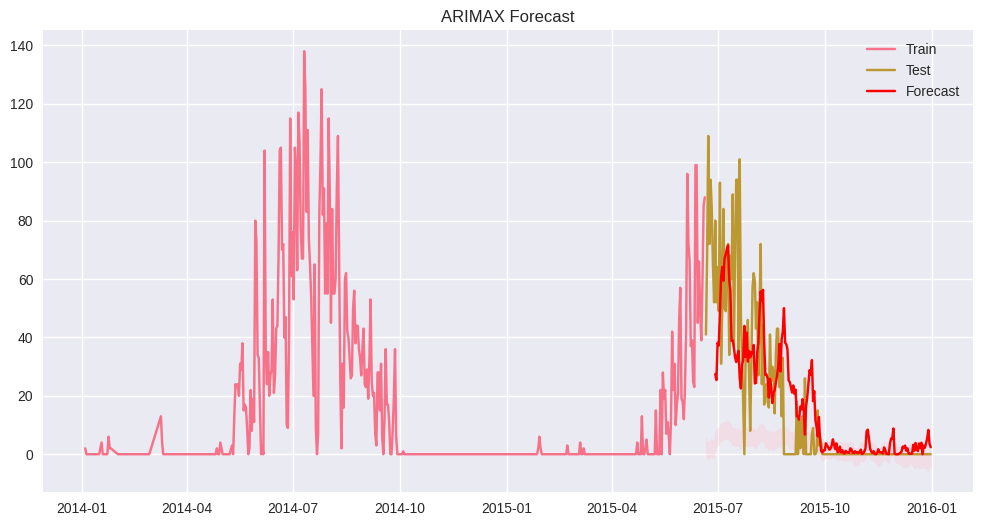

In [98]:
# Forecast
forecast = model_fit.get_forecast(steps=forecast_steps, exog=lags_tr.transform(x_test).fillna(0))
forecast_mean = forecast.predicted_mean**2
forecast_mean[forecast_mean < 0] = 0 
conf_int = forecast.conf_int()

# Plot results
plt.figure(figsize=(12,6))
plt.plot(y_train.index,y_train, label='Train')
plt.plot(y_test.index, y_test, label='Test')
plt.plot(y_test.index[8:], forecast_mean[8:], label='Forecast', color='red')
plt.fill_between(y_test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.legend()
plt.title('ARIMAX Forecast')
plt.show()

In [99]:
models =  pd.DataFrame({
    'model ': pd.Series(dtype='object'),
    'R2_test': pd.Series(dtype='float32'),  # pandas Boolean (supports NA)
    'MSE_test': pd.Series(dtype='float32') , 

})



In [100]:
r_squared = r2_score(y_test,  forecast_mean )
mse = mean_squared_error(y_test ,  forecast_mean )

In [101]:


print(f"Best model MsE: {mse:.2f}")


print(f"Best model R2: {r_squared*100:.2f} %")

Best model MsE: 494.68
Best model R2: 32.12 %


In [102]:
models.loc[len(models)] = ['SARIMAX' , r_squared , mse]

In [103]:
models

,model,R2_test,MSE_test
0,SARIMAX,0.321226,494.676987


In [104]:


def sarimax_diagnostic_plots(model, y, X=None, lags=10, figsize=(12, 8)):
    """
    Comprehensive diagnostics for SARIMAX models.
    
    Parameters:
    -----------
    model : Fitted SARIMAX/ARIMA model (statsmodels).
    y     : Actual time series (pd.Series or np.array).
    X     : Exogenous variables (pd.DataFrame or np.array).
    lags  : Number of lags for ACF/PACF plots.
    figsize : Figure size.
    """
    
    # --- 1. Residuals ---
    residuals = model.resid
    fitted = model.fittedvalues
    
    # --- Set up subplots ---
    fig, axes = plt.subplots(3, 2, figsize=(figsize[0], figsize[1]*1.5))
    plt.suptitle("SARIMAX Model Diagnostics", y=1.02)
    
    # --- Plot 1: Residuals vs Time ---
    axes[0, 0].plot(residuals)
    axes[0, 0].axhline(0, color='r', linestyle='--')
    axes[0, 0].set_title("Residuals Over Time")
    axes[0, 0].set_xlabel("Time")
    axes[0, 0].set_ylabel("Residuals")
    
    # --- Plot 2: Histogram & KDE ---
    sns.histplot(residuals, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title("Distribution of Residuals")
    axes[0, 1].set_xlabel("Residuals")
    
    # --- Plot 3: Q-Q Plot ---
    qqplot(residuals, line='s', ax=axes[1, 0], fit=True)
    axes[1, 0].set_title("Q-Q Plot")
    
    # --- Plot 4: ACF of Residuals ---
    plot_acf(residuals, lags=lags, alpha=0.01, ax=axes[1, 1])
    axes[1, 1].set_title("ACF of Residuals")
    
    # --- Plot 5: Actual vs Fitted ---
    axes[2, 0].plot(y, label='Actual')
    axes[2, 0].plot(fitted, label='Fitted', alpha=0.7)
    axes[2, 0].set_title("Actual vs. Fitted Values")
    axes[2, 0].legend()
    
    # --- Plot 6: PACF of Residuals ---
    plot_pacf(residuals, lags=lags, alpha=0.01, method='ywm', ax=axes[2, 1])
    axes[2, 1].set_title("PACF of Residuals")
    
    plt.tight_layout()
    plt.show()
    
    # --- Statistical Tests ---
    print("\n--- Statistical Tests ---")
    
    # 1. Ljung-Box Test (for autocorrelation)
    lb_test = acorr_ljungbox(residuals, lags=[lags], return_df=True)
    print(f"Ljung-Box Test (p-value): {lb_test['lb_pvalue'].values[0]:.4f}")
    if lb_test['lb_pvalue'].values[0] > 0.01:
        print("✓ Residuals are uncorrelated (white noise).")
    else:
        print("✗ Residuals show autocorrelation.")
    
    # 2. Normality Test (Shapiro-Wilk)
    from scipy.stats import shapiro
    shapiro_test = shapiro(residuals)
    print(f"Shapiro-Wilk Test (p-value): {shapiro_test[1]:.4f}")
    if shapiro_test[1] > 0.01:
        print("✓ Residuals are normally distributed.")
    else:
        print("✗ Residuals deviate from normality.")
    
    # --- Exogenous Variable (X) Validation ---
    if X is not None:
        print("\n--- Exogenous Variable (X) Diagnostics ---")
        
        # 1. Check Stationarity (ADF Test)
        print("\nStationarity of Exogenous Variables:")
        for col in X.columns:
            adf_result = adfuller(X[col].dropna())
            print(f"{col}: ADF p-value = {adf_result[1]:.4f}", end=" ")
            if adf_result[1] < 0.01:
                print("✓ Stationary")
            else:
                print("✗ Non-stationary (consider differencing/transforms)")
        
        # 2. Granger Causality (if feasible)
        try:
            from statsmodels.tsa.stattools import grangercausalitytests
            print("\nGranger Causality (maxlag=2):")
            test_result = grangercausalitytests(pd.DataFrame({'y': y, 'x': X.iloc[:, 0]}), maxlag=2, verbose=False)
            p_values = [round(test_result[i+1][0]['ssr_chi2test'][1], 4) for i in range(2)]
            print(f"Lag 1 p-value: {p_values[0]}, Lag 2 p-value: {p_values[1]}")
            if any(np.array(p_values) < 0.01):
                print("✓ X Granger-causes y (relevant exogenous variable).")
            else:
                print("✗ X does NOT Granger-cause y (may be irrelevant).")
        except Exception as e:
            print(f"Granger causality test skipped: {e}")

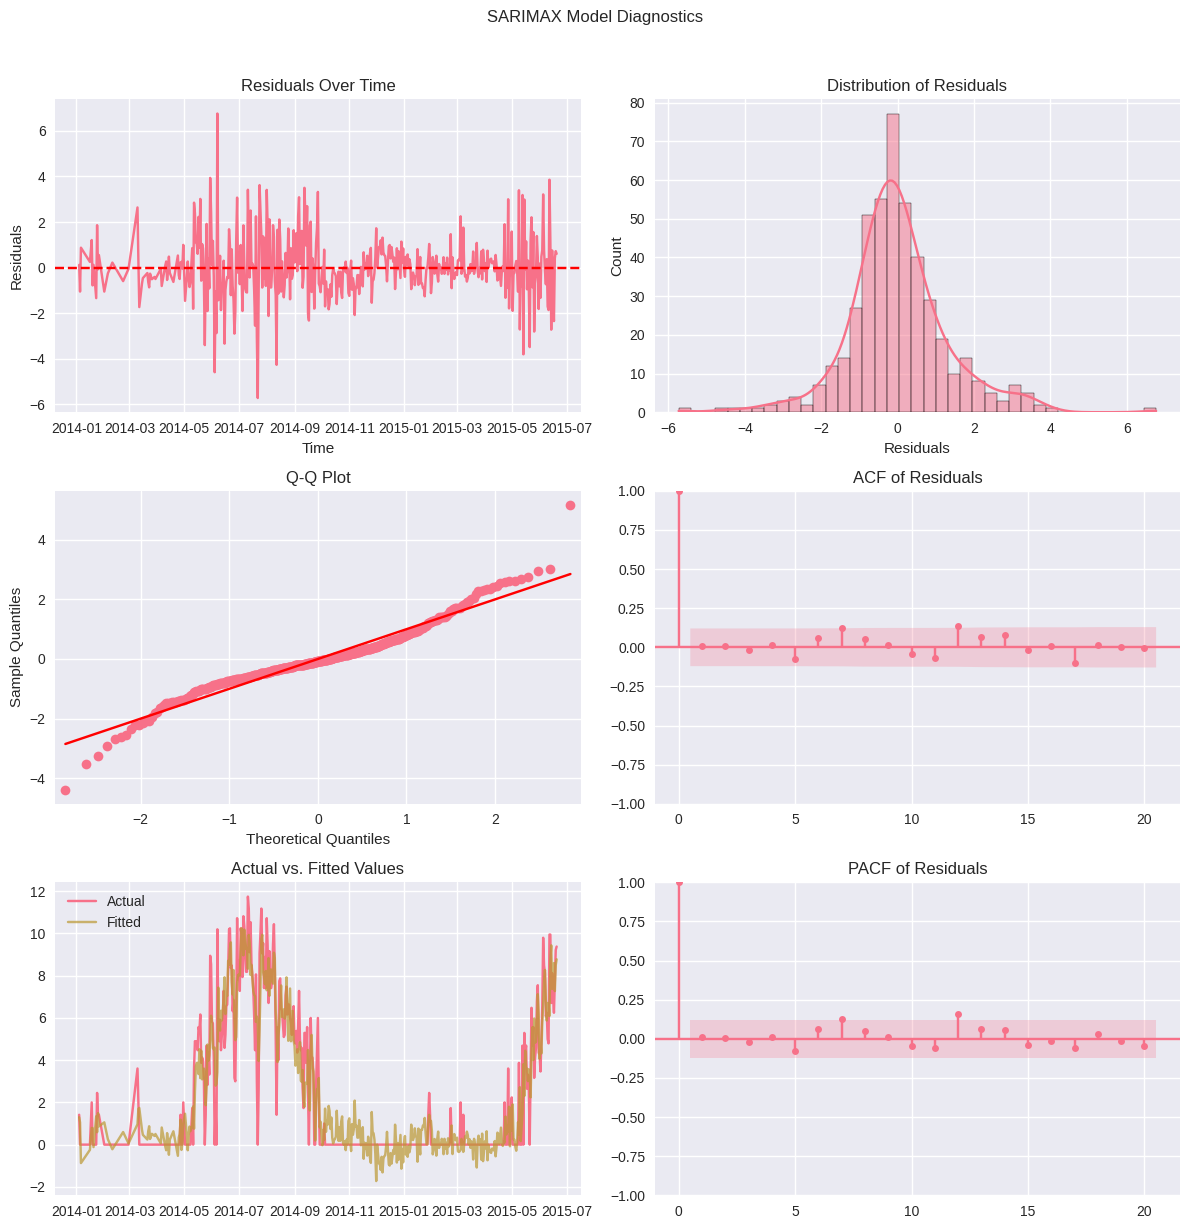


--- Statistical Tests ---
Ljung-Box Test (p-value): 0.0239
✓ Residuals are uncorrelated (white noise).
Shapiro-Wilk Test (p-value): 0.0000
✗ Residuals deviate from normality.

--- Exogenous Variable (X) Diagnostics ---

Stationarity of Exogenous Variables:
Battery Voltage AVG: ADF p-value = 0.0000 ✓ Stationary
Temperature AVG: ADF p-value = 0.1795 ✗ Non-stationary (consider differencing/transforms)
Relative Humidity AVG: ADF p-value = 0.0000 ✓ Stationary
Wind Speed Daily AVG: ADF p-value = 0.0000 ✓ Stationary
Wind Direction AVG: ADF p-value = 0.0096 ✓ Stationary
Solare Radiation AVG: ADF p-value = 0.1082 ✗ Non-stationary (consider differencing/transforms)
weekday: ADF p-value = 0.0001 ✓ Stationary
month: ADF p-value = 0.3051 ✗ Non-stationary (consider differencing/transforms)

Granger Causality (maxlag=2):
Granger causality test skipped: x contains NaN or inf values.


In [105]:
# Run diagnostics
sarimax_diagnostic_plots(model_fit, np.sqrt(y_train), X=x_final, lags=20)

## Prophet

In [106]:
tr_start,  tr_end , = '2014-01-04','2015-06-20'
#val_start, val_end = '2015-06-21','2015-09-25'
te_start, te_end = '2015-06-21','2015-12-31'
x_train , x_test = X[tr_start : tr_end] , X[te_start :te_end]
y_train , y_test =  y[tr_start : tr_end] , y[te_start :te_end]

In [107]:
# !pip install prophet
# lags_tr.transform(x_train).fillna(0)

In [108]:
x_train.columns

Index(['Battery Voltage AVG', 'Temperature AVG', 'Relative Humidity AVG',
       'Wind Speed Daily AVG', 'Wind Direction AVG', 'Solare Radiation AVG',
       'weekday', 'month'],
      dtype='object')

In [109]:
from prophet import Prophet

model = Prophet( growth="linear" ,
    yearly_seasonality=True,    # Keep default annual trends (e.g., summer vs. winter)
    weekly_seasonality=True,    # Keep if day-of-week patterns matter (e.g., weekends)
    daily_seasonality=False,   # Disable for daily data (unless intra-day patterns exist)
)
for i in x_train.columns : 
    model.add_regressor(i)
# Add custom 120-day seasonality (fourier_order controls flexibility)
model.add_seasonality(
    name='120day_cycle', 
    period=30,                 # Period length in days
    fourier_order=3            # Higher = more flexible fit (start with 3-8)
)

In [110]:
df_train = pd.concat([np.sqrt(y_train),x_train] , axis=1)

In [111]:
df_train['y'] = df_train['Succeeded']

In [112]:
df_train['ds'] = df_train.index

In [113]:
model.fit(df_train)


18:16:31 - cmdstanpy - INFO - Chain [1] start processing
18:16:31 - cmdstanpy - INFO - Chain [1] done processing


In [114]:
df_test = pd.concat([np.sqrt(y_test),x_test] , axis=1)

In [115]:
df_test['y'] = df_test['Succeeded']

In [116]:
df_test['ds'] = df_test.index

In [117]:
forecast = model.predict(df_test)


In [118]:
test_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(len(y_test))
test_forecast = test_forecast.set_index('ds')

In [119]:
y_pred = test_forecast["yhat"]**2

In [120]:
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test ,  y_pred)

print(f"Best model MsE: {mse:.2f}")


print(f"Best model R2: {r_squared*100:.2f} %")

Best model MsE: 335.64
Best model R2: 53.95 %


In [121]:
models.loc[len(models)] = ['PROPHET' , r_squared , mse]

In [122]:
models


,model,R2_test,MSE_test
0,SARIMAX,0.321226,494.676987
1,PROPHET,0.539454,335.636976


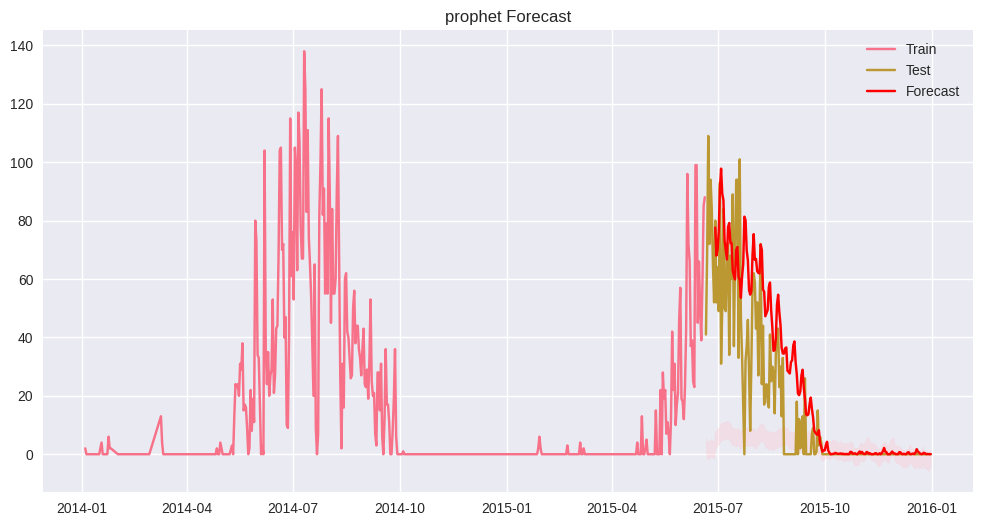

In [123]:
# Plot results
plt.figure(figsize=(12,6))
plt.plot(y_train.index,y_train, label='Train')
plt.plot(y_test.index, y_test, label='Test')
plt.plot(y_test.index[8:], (test_forecast["yhat"]**2)[8:], label='Forecast', color='red')
plt.fill_between(y_test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.legend()
plt.title('prophet Forecast')
plt.show()

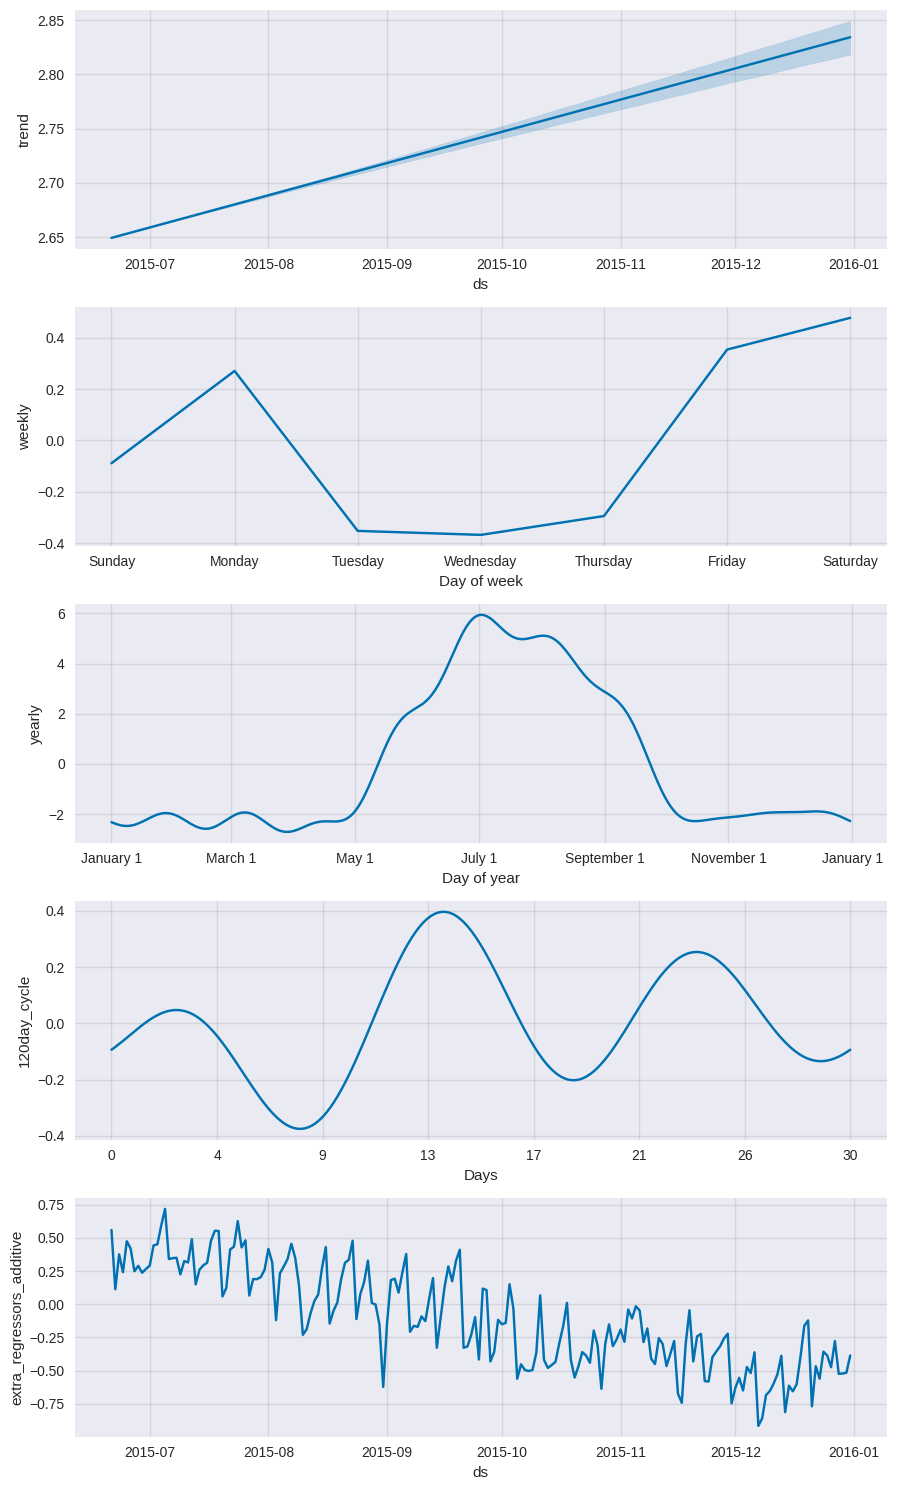

In [124]:
fig = model.plot_components(forecast)


In [125]:
# Get regressor coefficients
regressor_coeffs = pd.DataFrame({
    'regressor': model.extra_regressors.keys(),
    'mean_effect': [abs(forecast[col].mean()) for col in model.extra_regressors.keys()]
})



<Axes: xlabel='regressor'>

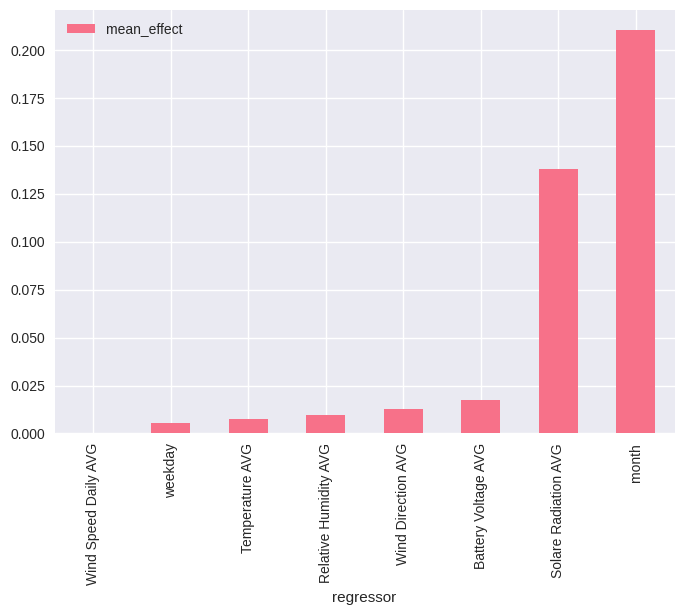

In [126]:
regressor_coeffs.index = regressor_coeffs['regressor']
regressor_coeffs.sort_values(by=['mean_effect']).head(10).plot(kind='bar')

In [127]:
tr_start,  tr_end , = '2014-01-04','2015-06-20'
#val_start, val_end = '2015-06-21','2015-09-25'
te_start, te_end = '2015-06-21','2015-12-31'

x_train , x_test = x_final[tr_start : tr_end] , x_final[te_start :te_end]
y_train , y_test =  y[tr_start : tr_end] , y[te_start :te_end]

In [128]:
train_sets = []
val_sets = []

In [129]:
x_train['lag_y'] = y_train.shift(1)


In [130]:
x_train

,Battery Voltage AVG,Temperature AVG,Relative Humidity AVG,Wind Speed Daily AVG,Wind Direction AVG,Solare Radiation AVG,weekday,month,lag_y
Date,,,,,,,,,
2014-01-04,13.418750,20.746667,93.022917,43.286667,277.700000,0.000000,5,1,NaN
2014-01-05,13.305833,28.823333,80.260833,42.825417,297.620833,0.000000,6,1,2.0
2014-01-06,13.549583,36.910000,21.617500,18.962500,278.133333,0.000000,0,1,0.0
2014-01-16,13.678333,18.130000,44.974167,16.174917,251.220833,0.000000,3,1,0.0
2014-01-18,13.478750,13.492500,96.029167,45.288750,204.462500,0.000000,5,1,0.0
...,...,...,...,...,...,...,...,...,...
2015-06-16,13.566250,38.616667,33.182917,9.260917,28.182083,352.221167,1,6,66.0
2015-06-17,13.509167,40.297083,39.140000,9.701375,19.752917,358.033292,2,6,50.0
2015-06-18,13.580833,33.132917,74.277917,29.122917,112.528750,244.179292,3,6,39.0


In [131]:
x_test['lag_y'] = y_test.shift(1)


In [132]:

# Initialize splitter
tscv = TimeSeriesSplit(n_splits=5)
# Visualize splits


## Light GBM

In [133]:
tr_start,  tr_end , = '2014-01-04','2015-06-20'
#val_start, val_end = '2015-06-21','2015-09-25'
te_start, te_end = '2015-06-21','2015-12-31'

x_train , x_test = x_final[tr_start : tr_end] , x_final[te_start :te_end]
y_train , y_test =  y[tr_start : tr_end] , y[te_start :te_end]

In [134]:
x_train['lag_y'] = y_train.shift(1)
x_test['lag_y'] = y_test.shift(1)

In [135]:
from sklearn.pipeline import Pipeline

import lightgbm as lgb
# Create dataset for LightGBM
model = lgb.LGBMRegressor(verbose=-1)  # Silent mode



pipeline = Pipeline([
        ('lags', TimeSeriesLagTransformer(columns = climate_features + ['lag_y'])),
        ('lgbm', lgb.LGBMRegressor(verbose=-1, random_state=42))
    ])
# Hyperparameter grid
param_grid = {
    'lgbm__num_leaves': [8,12 ],          # Control model complexity
    'lgbm__learning_rate': [0.05, 0.1],     # Step size
    'lgbm__n_estimators': [ 500 , 1000],       # Number of trees
    'lgbm__min_child_samples': [5, 10]      # Prevent overfitting
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=tscv,                         # Use TimeSeriesSplit
    scoring='neg_mean_absolute_error', # Metric to optimize
    n_jobs=-1                         # Parallelize if possible
)



# Fit on features (X) and target (y)
grid_search.fit(x_train, y_train)

# Best hyperparameters
print("Best params:", grid_search.best_params_)




Best params: {'lgbm__learning_rate': 0.1, 'lgbm__min_child_samples': 10, 'lgbm__n_estimators': 1000, 'lgbm__num_leaves': 12}


In [136]:
# CV results (MAE per fold)
cv_results = pd.DataFrame(grid_search.cv_results_)
print(cv_results[['params', 'mean_test_score', 'std_test_score']])

# Best model's validation MAE
best_model = grid_search.best_estimator_
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)



                                               params  mean_test_score  \
0   {'lgbm__learning_rate': 0.05, 'lgbm__min_child...       -11.581587   
1   {'lgbm__learning_rate': 0.05, 'lgbm__min_child...       -11.467827   
2   {'lgbm__learning_rate': 0.05, 'lgbm__min_child...       -11.615338   
3   {'lgbm__learning_rate': 0.05, 'lgbm__min_child...       -11.473502   
4   {'lgbm__learning_rate': 0.05, 'lgbm__min_child...       -11.417483   
5   {'lgbm__learning_rate': 0.05, 'lgbm__min_child...       -11.135277   
6   {'lgbm__learning_rate': 0.05, 'lgbm__min_child...       -11.393804   
7   {'lgbm__learning_rate': 0.05, 'lgbm__min_child...       -11.107228   
8   {'lgbm__learning_rate': 0.1, 'lgbm__min_child_...       -11.726191   
9   {'lgbm__learning_rate': 0.1, 'lgbm__min_child_...       -11.347770   
10  {'lgbm__learning_rate': 0.1, 'lgbm__min_child_...       -11.729346   
11  {'lgbm__learning_rate': 0.1, 'lgbm__min_child_...       -11.347739   
12  {'lgbm__learning_rate': 0.1, 'lgbm

In [137]:
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test ,  y_pred )
print(f"Best model MsE: {mse:.2f}")


print(f"Best model R2: {r_squared*100:.2f} %")

Best model MsE: 253.27
Best model R2: 65.25 %


In [138]:
models.loc[len(models)] = ['Light GBM' , r_squared , mse]

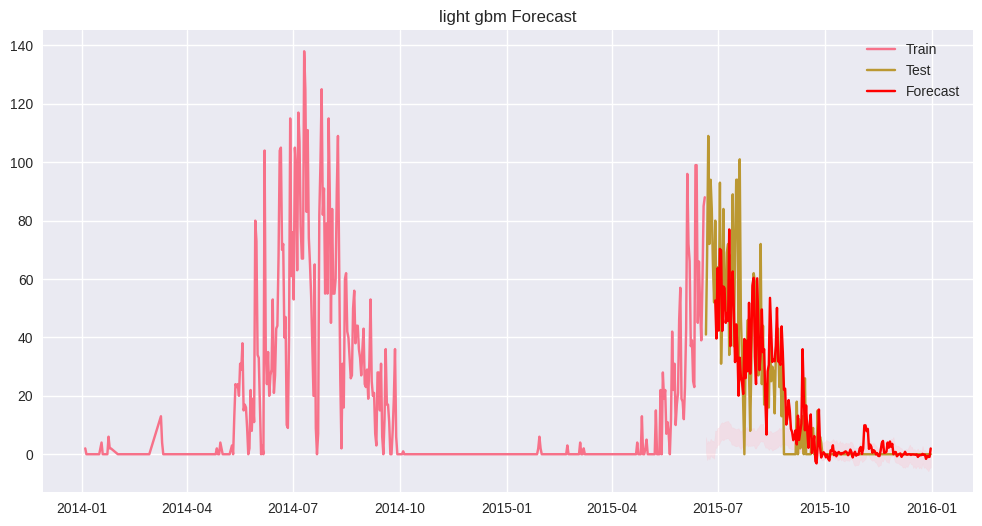

In [139]:
# Plot results
plt.figure(figsize=(12,6))
plt.plot(y_train.index,y_train, label='Train')
plt.plot(y_test.index, y_test, label='Test')
plt.plot(y_test.index[8:], y_pred[8:], label='Forecast', color='red')
plt.fill_between(y_test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.legend()
plt.title('light gbm Forecast')
plt.show()

## LSTM

In [140]:
tr_start,  tr_end , = '2014-01-04','2015-06-20'
#val_start, val_end = '2015-06-21','2015-09-25'
te_start, te_end = '2015-06-21','2015-12-31'

x_train , x_test = x_final[tr_start : tr_end] , x_final[te_start :te_end]
y_train , y_test =  y[tr_start : tr_end] , y[te_start :te_end]

In [141]:
 # x_train = TimeSeriesLagTransformer(columns=climate_features).transform(x_train).fillna(0)
 # x_test =  TimeSeriesLagTransformer(columns=climate_features).transform(x_train).fillna(0)

In [142]:
x_train

,Battery Voltage AVG,Temperature AVG,Relative Humidity AVG,Wind Speed Daily AVG,Wind Direction AVG,Solare Radiation AVG,weekday,month
Date,,,,,,,,
2014-01-04,13.418750,20.746667,93.022917,43.286667,277.700000,0.000000,5,1
2014-01-05,13.305833,28.823333,80.260833,42.825417,297.620833,0.000000,6,1
2014-01-06,13.549583,36.910000,21.617500,18.962500,278.133333,0.000000,0,1
2014-01-16,13.678333,18.130000,44.974167,16.174917,251.220833,0.000000,3,1
2014-01-18,13.478750,13.492500,96.029167,45.288750,204.462500,0.000000,5,1
...,...,...,...,...,...,...,...,...
2015-06-16,13.566250,38.616667,33.182917,9.260917,28.182083,352.221167,1,6
2015-06-17,13.509167,40.297083,39.140000,9.701375,19.752917,358.033292,2,6
2015-06-18,13.580833,33.132917,74.277917,29.122917,112.528750,244.179292,3,6


    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
        
    model.add(LSTM(32))
    model.add(Dropout(0.2))

    model.add(Dense(16, activation='relu'))
    model.add(Dense(output_units, activation='linear'))
    

In [143]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout , BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Assuming x_train, y_train, x_test, y_test are already defined

# Reshape input data for LSTM [samples, time steps, features]
def prepare_data_for_lstm(x_data, y_data, time_steps=1):
    # Reshape x_data to [samples, time_steps, features]
    if len(x_data.shape) == 2:
        n_samples, n_features = x_data.shape
        x_reshaped = np.array(x_data).reshape((n_samples, time_steps, n_features))
    else:
        x_reshaped = x_data  # Assume it's already in the right shape
    
    return x_reshaped, np.array(y_data)

# Normalize the data and retain scalers for inverse transformation
def normalize_data(x_train, y_train, x_test, y_test):
    # Create and fit scalers
    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()
    
    # Get dimensions
    n_samples_train = x_train.shape[0]
    n_features = x_train.shape[-1]  # Last dimension is features
    
    # Scale x_train
    x_train_scaled = x_scaler.fit_transform(x_train.reshape(-1, n_features))
    x_train_scaled = x_train_scaled.reshape(x_train.shape)
    
    # Scale x_test
    n_samples_test = x_test.shape[0]
    x_test_scaled = x_scaler.transform(x_test.reshape(-1, n_features))
    x_test_scaled = x_test_scaled.reshape(x_test.shape)
    
    # Scale y data
    # Reshape y if needed (1D to 2D)
    y_train_2d = y_train.reshape(-1, 1) if len(y_train.shape) == 1 else y_train
    y_test_2d = y_test.reshape(-1, 1) if len(y_test.shape) == 1 else y_test
    
    y_train_scaled = y_scaler.fit_transform(y_train_2d)
    y_test_scaled = y_scaler.transform(y_test_2d)
    
    # Convert back to original shape if y was 1D
    if len(y_train.shape) == 1:
        y_train_scaled = y_train_scaled.flatten()
        y_test_scaled = y_test_scaled.flatten()
    
    return x_train_scaled, y_train_scaled, x_test_scaled, y_test_scaled, x_scaler, y_scaler

# Create and train LSTM model
def create_and_train_lstm_model(x_train, y_train, validation_split=0.3):
    # Get the input shape
    input_shape = (x_train.shape[1], x_train.shape[2])
    
    # Determine if the task is classification or regression
    if len(np.unique(y_train)) <= 10:  # Classification with few classes
        output_units = len(np.unique(y_train))
        loss = 'sparse_categorical_crossentropy' if output_units > 2 else 'binary_crossentropy'
        activation = 'softmax' if output_units > 2 else 'sigmoid'
    else:  # Regression or multi-class with many classes
        output_units = y_train.shape[1] if len(y_train.shape) > 1 else 1
        loss = 'mae'
        activation = 'linear'
    
    # Define model architecture
    model = Sequential()
        # Medium-depth architecture with 3 LSTM layers
    model.add(LSTM(512, return_sequences=True, input_shape=input_shape))
    # model.add(BatchNormalization())

    model.add(Dropout(0.25))



    model.add(LSTM(256, return_sequences=True))
    # model.add(BatchNormalization())

    model.add(Dropout(0.25))

    
    model.add(LSTM(64))
    model.add(Dropout(0.25))


    model.add(Dense(8, activation='relu'))


    model.add(Dense(output_units, activation='linear'))
    
    # Compile model
    model.compile(optimizer='adam', loss=loss, 
                 metrics=['accuracy'] if loss != 'mae' else ['mae'])
    
    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    # Train model
    history = model.fit(
        x_train, y_train,
        epochs=100,
        batch_size=16,
        validation_split=validation_split,
        callbacks=[early_stopping],
        verbose=1
    )
    
    return model, history

# Make predictions and inverse transform
def predict_and_evaluate(model, x_test_scaled, y_test, y_scaler):
    # Make predictions
    y_pred_scaled = model.predict(x_test_scaled)
    
    # Reshape if needed for inverse transform
    if len(y_pred_scaled.shape) == 1:
        y_pred_scaled = y_pred_scaled.reshape(-1, 1)
    
    # Inverse transform predictions
    y_pred = (y_scaler.inverse_transform(y_pred_scaled))
    
    # Reshape y_test for inverse transform if needed
    y_test_2d = y_test.reshape(-1, 1) if len(y_test.shape) == 1 else y_test
    y_test_original = y_scaler.inverse_transform(y_test_2d)
    
    # Flatten if original was 1D
    if len(y_test.shape) == 1:
        y_pred = y_pred.flatten()
        y_test_original = y_test_original.flatten()
    
    # Calculate R-squared
    r2 = r2_score(y_test_original, y_pred)
    print(f"R-squared: {r2:.4f}")
    
    return y_pred, r2

# Main execution
def train_and_evaluate_lstm(x_train, y_train, x_test, y_test, time_steps=1):
    # Prepare data
    x_train_reshaped, y_train = prepare_data_for_lstm(x_train, y_train, time_steps)
    x_test_reshaped, y_test = prepare_data_for_lstm(x_test, y_test, time_steps)
    
    # Normalize
    x_train_scaled, y_train_scaled, x_test_scaled, y_test_scaled, x_scaler, y_scaler = normalize_data(
        x_train_reshaped, y_train, x_test_reshaped, y_test
    )
    
    # Train model
    model, history = create_and_train_lstm_model(x_train_scaled, y_train_scaled)
    
    print("Model training complete!")
    
    # Make predictions and evaluate
    y_pred, r2 = predict_and_evaluate(model, x_test_scaled, y_test_scaled, y_scaler)
    
    return model, history, y_pred, r2, x_scaler, y_scaler

# Example usage:
# model, history, y_pred, r2, x_scaler, y_scaler = train_and_evaluate_lstm(x_train, y_train, x_test, y_test)



2025-04-23 18:17:36.594784: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745432256.877612      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745432256.959579      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [144]:
# Assuming you have x_train, y_train, x_test, y_test ready
model, history, y_pred, r2, x_scaler, y_scaler = train_and_evaluate_lstm(x_train, y_train, x_test, y_test)

# Visualize the results


2025-04-23 18:17:52.661262: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - loss: 0.1449 - mae: 0.1449 - val_loss: 0.0678 - val_mae: 0.0678
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1163 - mae: 0.1163 - val_loss: 0.0450 - val_mae: 0.0450
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0865 - mae: 0.0865 - val_loss: 0.0450 - val_mae: 0.0450
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0865 - mae: 0.0865 - val_loss: 0.0446 - val_mae: 0.0446
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0805 - mae: 0.0805 - val_loss: 0.0434 - val_mae: 0.0434
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0920 - mae: 0.0920 - val_loss: 0.0480 - val_mae: 0.0480
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0859 - mae: 0.0859 - val_loss: 0.0438 - val_mae: 0.0438
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0928 - mae: 0.0928 - val_loss: 0.0439 - val_mae: 0.0439
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - l

In [145]:
r_squared = r2_score(y_test[8:], y_pred[8:])

In [146]:
print (f" the R2 on test set : {r2_score(y_test, y_pred)*100:.2f} % ")

 the R2 on test set : 60.62 % 


In [147]:
mse = mean_squared_error(y_test, y_pred)
print(f"Best model MsE: {mse:.2f}")


Best model MsE: 286.96


In [148]:
models.loc[len(models)] = ['LSTM' , r_squared , mse]

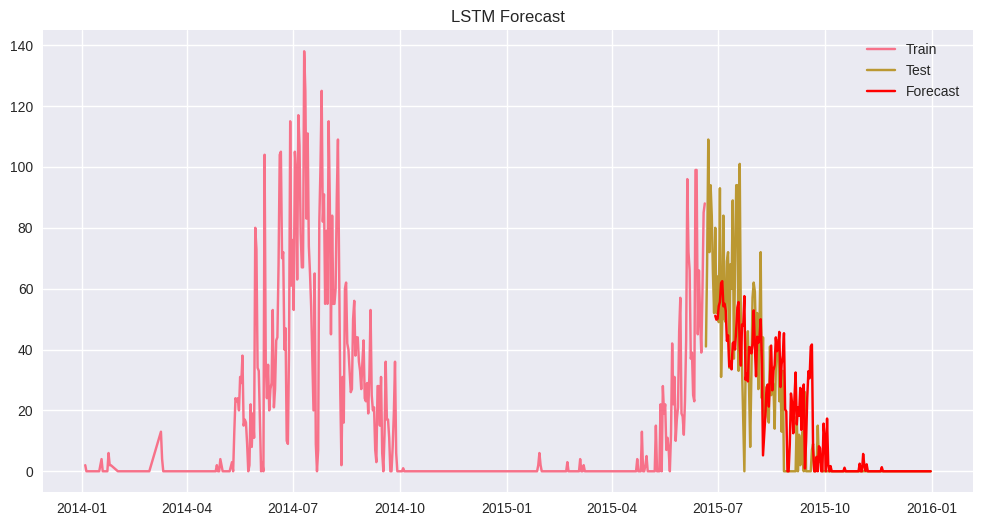

In [149]:
# Plot results
plt.figure(figsize=(12,6))
plt.plot(y_train.index,y_train, label='Train')
plt.plot(y_test.index, y_test, label='Test')
plt.plot(y_test.index[8:], y_pred[8:], label='Forecast', color='red')
plt.legend()
plt.title('LSTM Forecast')
plt.show()

# Conclusion

In [150]:
models.sort_values(by=['MSE_test'] , ascending=True)

,model,R2_test,MSE_test
2,Light GBM,0.652481,253.265003
3,LSTM,0.594544,286.957792
1,PROPHET,0.539454,335.636976
0,SARIMAX,0.321226,494.676987


We find that the best performing model in our case is Light GBM 